# COVID-19 PATIENT PRECONDITION ANALYSIS

## SETUP ENVIRONMENT

In [74]:
import os
import sys

# # Clone repository (Update with your actual URL)
# !rm -rf Covid_Project
# !git clone https://github.com/YourUsername/RepoName.git

# # Append path to recognize modules
# sys.path.append('/content/Covid_Project')

# # Install dependencies
# !pip install -r /content/Covid_Project/requirements.txt

In [75]:
! pip install -r requirements.txt

In [76]:
! pip install --upgrade scikit-learn xgboost lightgbm catboost imblearn

In [77]:
!pip install --upgrade torch torchvision torchaudio

In [78]:
! pip install tensorflow pytorch_tabnet

In [79]:
# Import Custom Modules
import modules
from modules.config import DATASET_URL, DATA_PATH, CATEGORICAL_FEATURES, NUMERICAL_FEATURES, TARGET_COLUMN, ORDINAL_FEATURES
from modules.data_loader import download_and_load
from modules.preprocessing import clean_data, convert_cat, apply_feature_binning, get_preprocessor
from modules.eda import plot_categorical_distribution,plot_numerical_distribution, plot_correlation, plot_categorical_heatmap, plot_categorical_importance
from modules.utils import display_unique_values
from modules.models import tune_base_models, evaluate_model, generate_balanced_datasets, train_and_evaluate_pipeline
import pandas as pd
from modules.deep_learning import evaluate_dl_model, evaluate_resnet_model, evaluate_tabnet_model
from imblearn.under_sampling import RandomUnderSampler

print("Modules loaded successfully!")

Modules loaded successfully!


## 1. Data Acquisition

In [80]:
# Load raw data
df_raw = download_and_load(DATASET_URL, DATA_PATH)
df_raw.head()

,id,sex,patient_type,entry_date,date_symptoms,date_died,intubed,pneumonia,age,pregnancy,...,inmsupr,hypertension,other_disease,cardiovascular,obesity,renal_chronic,tobacco,contact_other_covid,covid_res,icu
0,16169f,2,1,04-05-2020,02-05-2020,9999-99-99,97,2,27,97,...,2,2,2,2,2,2,2,2,1,97
1,1009bf,2,1,19-03-2020,17-03-2020,9999-99-99,97,2,24,97,...,2,2,2,2,2,2,2,99,1,97
2,167386,1,2,06-04-2020,01-04-2020,9999-99-99,2,2,54,2,...,2,2,2,2,1,2,2,99,1,2
3,0b5948,2,2,17-04-2020,10-04-2020,9999-99-99,2,1,30,97,...,2,2,2,2,2,2,2,99,1,2
4,0d01b5,1,2,13-04-2020,13-04-2020,22-04-2020,2,2,60,2,...,2,1,2,1,2,2,2,99,1,2


In [81]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 566602 entries, 0 to 566601
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   id                   566602 non-null  str  
 1   sex                  566602 non-null  int64
 2   patient_type         566602 non-null  int64
 3   entry_date           566602 non-null  str  
 4   date_symptoms        566602 non-null  str  
 5   date_died            566602 non-null  str  
 6   intubed              566602 non-null  int64
 7   pneumonia            566602 non-null  int64
 8   age                  566602 non-null  int64
 9   pregnancy            566602 non-null  int64
 10  diabetes             566602 non-null  int64
 11  copd                 566602 non-null  int64
 12  asthma               566602 non-null  int64
 13  inmsupr              566602 non-null  int64
 14  hypertension         566602 non-null  int64
 15  other_disease        566602 non-null  int64
 16  cardiovascula

In [82]:
display_unique_values(df_raw)


SUMMARY: UNIQUE VALUES PER COLUMN
Feature: id
Values: <StringArray>
[  '16169f',   '1009bf',   '167386',   '0b5948',   '0d01b5',   '1beec8',
 '1.75E+56',   '0ce1f5',   '12b57a',   '006b91',
 ...
   '127b15',   '150615',   '11840d',   '1cab58', '1.44E+80',   '01ff60',
   '047cd1',   '1beb81',   '16fb02',   '0021c9']
Length: 563201, dtype: str
------------------------------
Feature: sex
Values: [2 1]
------------------------------
Feature: patient_type
Values: [1 2]
------------------------------
Feature: entry_date
Values: <StringArray>
['04-05-2020', '19-03-2020', '06-04-2020', '17-04-2020', '13-04-2020',
 '16-04-2020', '22-04-2020', '21-05-2020', '23-04-2020', '29-04-2020',
 ...
 '21-02-2020', '04-02-2020', '08-02-2020', '19-02-2020', '03-01-2020',
 '01-02-2020', '15-02-2020', '11-01-2020', '01-01-2020', '05-01-2020']
Length: 181, dtype: str
------------------------------
Feature: date_symptoms
Values: <StringArray>
['02-05-2020', '17-03-2020', '01-04-2020', '10-04-2020', '13-04-2020



*   **Categorical** = `sex`, `patient_type`, `intubed`, `pneumonia`, `pregnancy`, `diabetes`, `copd`, `asthma`,
       `inmsupr`, `hypertension`, `other_disease`, `cardiovascular`, `obesity`,
       `renal_chronic`, `tobacco`, `contact_other_covid`, `covid_res`, `icu`
*   **Numerical** = `age`
*   **Date** = `entry_date`, `date_symptoms`, `date_die`



## 2. Data Preprocessing
In this stage, we clean the data by:
- Creating the `is_dead` target variable.
- Standardizing missing codes (Grouping 98 into 99).
- Mapping 'No' values (2) to 0 for binary consistency.

In [83]:
# Execute cleaning pipeline
df_clean = clean_data(df_raw)
df_clean = convert_cat(df_clean)

# Check processed data info
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 566602 entries, 0 to 566601
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   sex                  566602 non-null  category
 1   patient_type         566602 non-null  category
 2   intubed              566602 non-null  category
 3   pneumonia            566602 non-null  category
 4   age                  566602 non-null  int64   
 5   pregnancy            566602 non-null  category
 6   diabetes             566602 non-null  category
 7   copd                 566602 non-null  category
 8   asthma               566602 non-null  category
 9   inmsupr              566602 non-null  category
 10  hypertension         566602 non-null  category
 11  other_disease        566602 non-null  category
 12  cardiovascular       566602 non-null  category
 13  obesity              566602 non-null  category
 14  renal_chronic        566602 non-null  category
 15  tobacco    

## 3. Exploratory Data Analysis (EDA)
We visualize the key features to understand the distribution of patient conditions.

Let's have a look at our dataset và its info

In [84]:
df_stats = df_clean.copy()

In [85]:
df_stats

,sex,patient_type,intubed,pneumonia,age,pregnancy,diabetes,copd,asthma,inmsupr,...,other_disease,cardiovascular,obesity,renal_chronic,tobacco,contact_other_covid,covid_res,icu,is_dead,delay_time
0,0,1,97,0,27,97,0,0,0,0,...,0,0,0,0,0,0,1,97,0,2
1,0,1,97,0,24,97,0,0,0,0,...,0,0,0,0,0,99,1,97,0,2
2,1,0,0,0,54,0,0,0,0,0,...,0,0,1,0,0,99,1,0,0,5
3,0,0,0,1,30,97,0,0,0,0,...,0,0,0,0,0,99,1,0,0,7
4,1,0,0,0,60,0,1,0,0,0,...,0,1,0,0,0,99,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566597,0,1,97,0,58,97,1,0,0,0,...,0,0,0,0,0,0,3,97,0,10
566598,1,1,97,0,48,0,0,0,0,0,...,0,0,0,0,0,0,3,97,0,1
566599,1,0,0,1,49,0,0,0,0,0,...,0,0,1,0,0,99,3,0,0,13
566600,1,1,97,1,43,0,0,0,0,0,...,0,0,0,0,0,0,3,97,0,2


In [86]:
df_stats.info()

<class 'pandas.DataFrame'>
RangeIndex: 566602 entries, 0 to 566601
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   sex                  566602 non-null  category
 1   patient_type         566602 non-null  category
 2   intubed              566602 non-null  category
 3   pneumonia            566602 non-null  category
 4   age                  566602 non-null  int64   
 5   pregnancy            566602 non-null  category
 6   diabetes             566602 non-null  category
 7   copd                 566602 non-null  category
 8   asthma               566602 non-null  category
 9   inmsupr              566602 non-null  category
 10  hypertension         566602 non-null  category
 11  other_disease        566602 non-null  category
 12  cardiovascular       566602 non-null  category
 13  obesity              566602 non-null  category
 14  renal_chronic        566602 non-null  category
 15  tobacco    

As you can see, though most features are in categorical type, their info is shown to be numerical (such as sex, patient_type, intubed...) Therefore, we would like to change their data types correctly into the exact ones first.

In [87]:
df_stats.columns

Index(['sex', 'patient_type', 'intubed', 'pneumonia', 'age', 'pregnancy',
       'diabetes', 'copd', 'asthma', 'inmsupr', 'hypertension',
       'other_disease', 'cardiovascular', 'obesity', 'renal_chronic',
       'tobacco', 'contact_other_covid', 'covid_res', 'icu', 'is_dead',
       'delay_time'],
      dtype='str')

As we've done, we now can see the data description to have more understandings

In [88]:
df_stats.describe()

,age,is_dead,delay_time
count,566602.000000,566602.000000,566602.000000
mean,42.622483,0.063847,3.665589
std,16.659973,0.244481,3.280740
min,0.000000,0.000000,0.000000
25%,31.000000,0.000000,1.000000
50%,41.000000,0.000000,3.000000
75%,53.000000,0.000000,5.000000
max,120.000000,1.000000,115.000000


Being the only **numerical feature**, `age` shows us that the average age of people in the dataset is aroung 42 years old, whereas the youngest was just a few months (0 years old), and the oldest was suprisingly 120.

We will find out more about this lovely feature later. Now, let's look at the catgorical features which we have changed their data type before

In [89]:
df_stats.describe(include='category')

,sex,patient_type,intubed,pneumonia,pregnancy,diabetes,copd,asthma,inmsupr,hypertension,other_disease,cardiovascular,obesity,renal_chronic,tobacco,contact_other_covid,covid_res,icu
count,566602,566602,566602,566602,566602,566602,566602,566602,566602,566602,566602,566602,566602,566602,566602,566602,566602,566602
unique,2,2,4,3,4,3,3,3,3,3,3,3,3,3,3,3,3,4
top,0,1,97,0,97,0,0,0,0,0,0,0,0,0,0,1,2,97
freq,287112,444689,444689,478416,287112,493790,555723,546824,555644,472270,546920,552005,472549,553560,516678,221867,279035,444689


This table allows us to find out how many unique values does each feature has, also their top-appeared value and its frequency. For example, if we look at `sex`, we'll know that there are 2 particular values, which is `0` (male) and `1` (female), and the most frequent is `0` (male), appearing 287.112 times.

Especially, if we carefully investigate, it's clear to see that `intubed`, `pregnancy`, `icu`, whose top-appeared value is `99` (means null value), are all needed to be preprocessed with special care later.

Now, let's dive into these features one by one

### **Target Feature - `is_dead`**

For easier use and analysis, we can change the labels of this feature into a more easily understanding words.

/home/thaoly/covid-19-classification/modules/eda.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=temp, x=column, hue=hue, palette=palette)


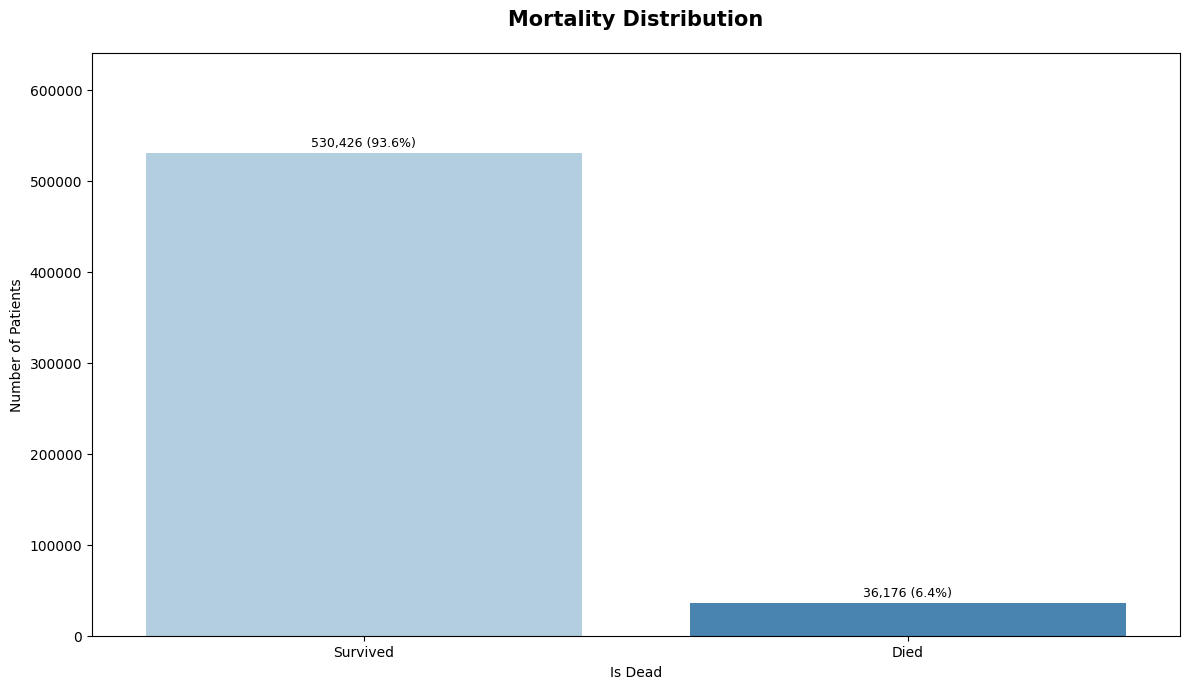


[SUMMARY TABLE: `is_dead`]
           Count Percentage (%)
is_dead                        
Survived  530426         93.62%
Died       36176          6.38%
------------------------------------------------------------



In [90]:
plot_categorical_distribution(df=df_stats, 
                              column=TARGET_COLUMN, 
                              title='Mortality Distribution',
                              mapping={1: 'Died', 0: 'Survived'})

### **Categorical Features**
`sex`, `patient_type`, `intubed`, `pneumonia`, `pregnancy`, `diabetes`, `copd`, `asthma`,
       `inmsupr`, `hypertension`, `other_disease`, `cardiovascular`, `obesity`,
       `renal_chronic`, `tobacco`, `contact_other_covid`, `covid_res`, `icu`,

#### ***Gender Distribution:*** `sex`

/home/thaoly/covid-19-classification/modules/eda.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=temp, x=column, hue=hue, palette=palette)


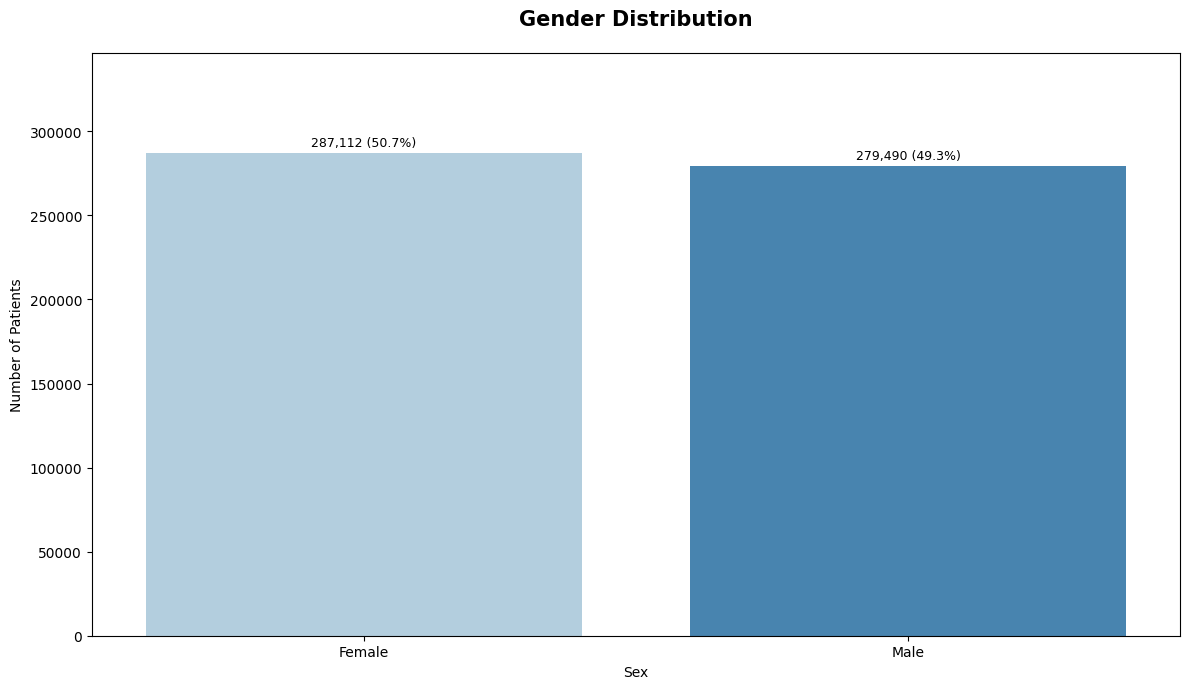


[SUMMARY TABLE: `sex`]
         Count Percentage (%)
sex                          
Female  287112         50.67%
Male    279490         49.33%
------------------------------------------------------------



In [91]:
plot_categorical_distribution(df=df_stats, 
                              column='sex', 
                              title='Gender Distribution',
                              mapping={ 1: 'Male', 0: 'Female'})

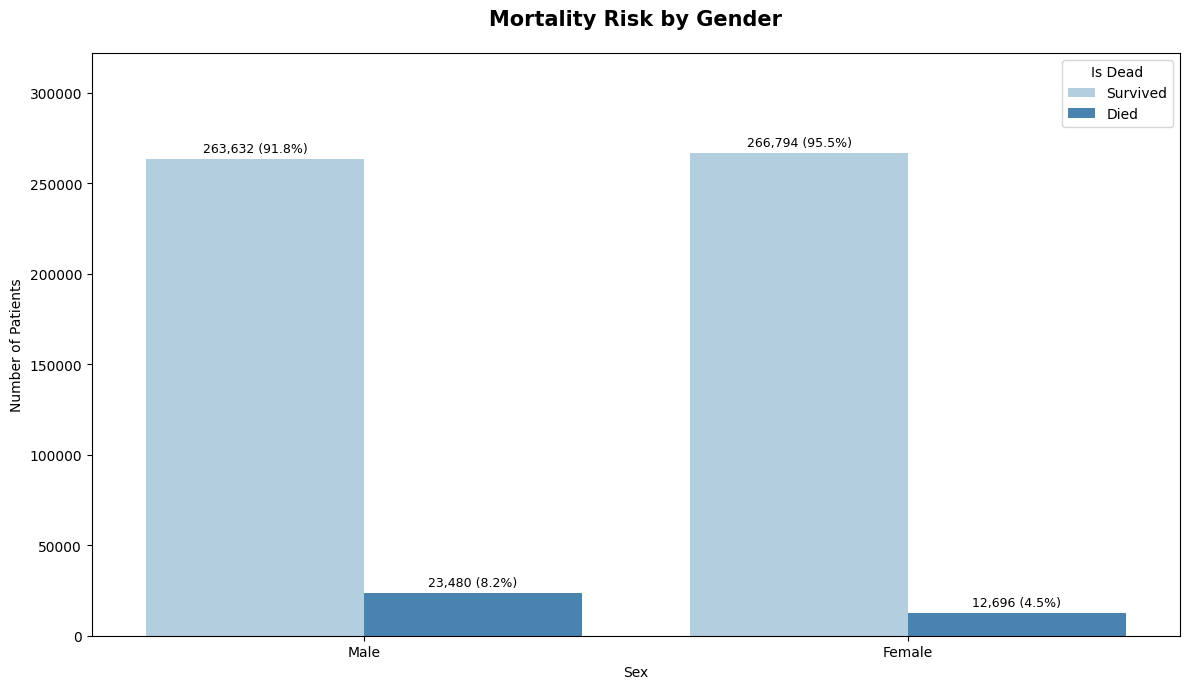


[SUMMARY TABLE: `sex` vs `is_dead`]

1. Raw Counts:
 is_dead   Died  Survived   Total
sex                             
Female   12696    266794  279490
Male     23480    263632  287112
Total    36176    530426  566602

2. Row-wise Percentage (Risk Analysis):
 is_dead   Died Survived
sex                    
Female   4.54%   95.46%
Male     8.18%   91.82%
------------------------------------------------------------



In [92]:
plot_categorical_distribution(df=df_stats, 
                  column='sex', 
                  hue='is_dead', 
                  title='Mortality Risk by Gender', 
                  mapping={'sex': {1: 'Female', 0: 'Male'}, 
                           'is_dead': {1: 'Died', 0: 'Survived'}})

#### `patient_type`

/home/thaoly/covid-19-classification/modules/eda.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=temp, x=column, hue=hue, palette=palette)


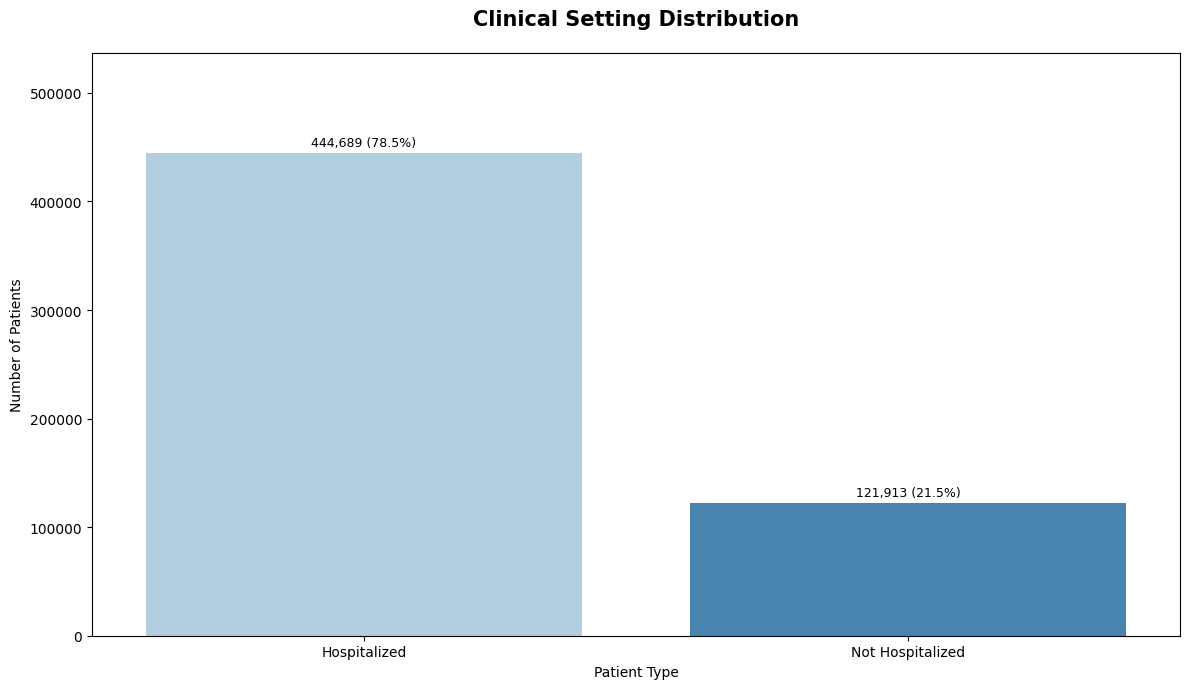


[SUMMARY TABLE: `patient_type`]
                   Count Percentage (%)
patient_type                           
Hospitalized      444689         78.48%
Not Hospitalized  121913         21.52%
------------------------------------------------------------



In [93]:
plot_categorical_distribution(df=df_stats, 
                  column='patient_type', 
                  title='Clinical Setting Distribution', 
                  mapping={0: 'Not Hospitalized', 1: 'Hospitalized'})

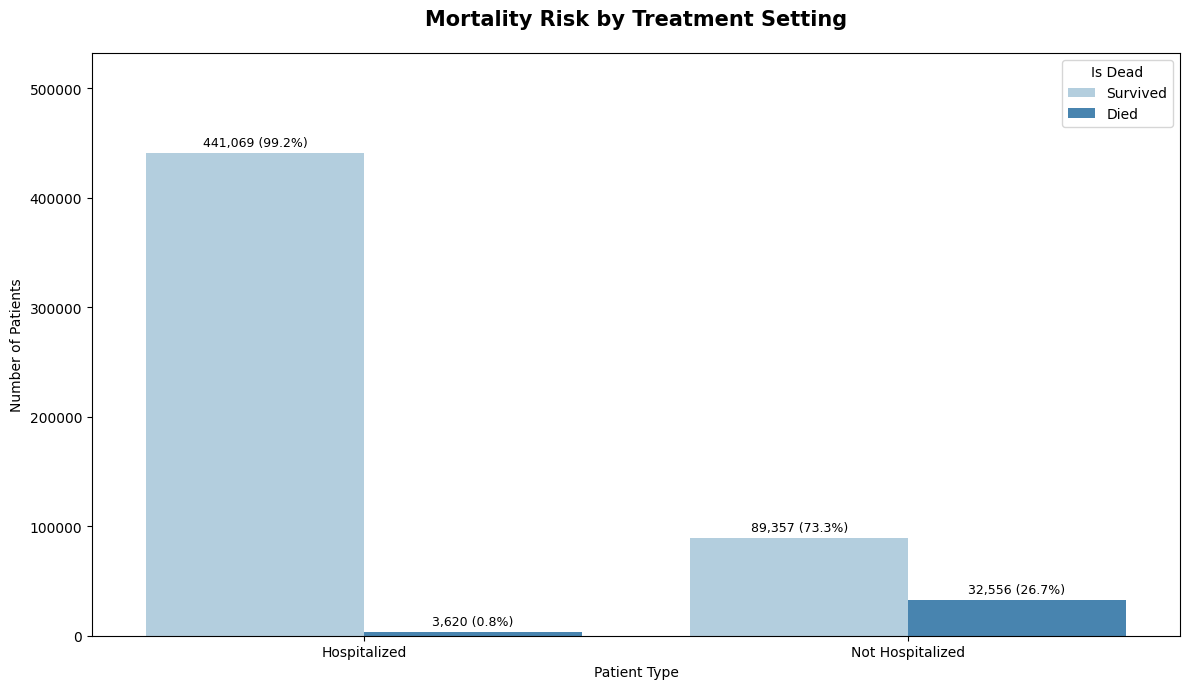


[SUMMARY TABLE: `patient_type` vs `is_dead`]

1. Raw Counts:
 is_dead            Died  Survived   Total
patient_type                             
Hospitalized       3620    441069  444689
Not Hospitalized  32556     89357  121913
Total             36176    530426  566602

2. Row-wise Percentage (Risk Analysis):
 is_dead            Died Survived
patient_type                    
Hospitalized      0.81%   99.19%
Not Hospitalized  26.7%    73.3%
------------------------------------------------------------



In [94]:
plot_categorical_distribution(df=df_stats, 
                  column='patient_type', 
                  hue='is_dead', 
                  title='Mortality Risk by Treatment Setting', 
                  mapping={
                      'patient_type':{0: 'Not Hospitalized', 1: 'Hospitalized'},
                      'is_dead': {1: 'Died', 0: 'Survived'}
                  })

#### `intubed`

/home/thaoly/covid-19-classification/modules/eda.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=temp, x=column, hue=hue, palette=palette)


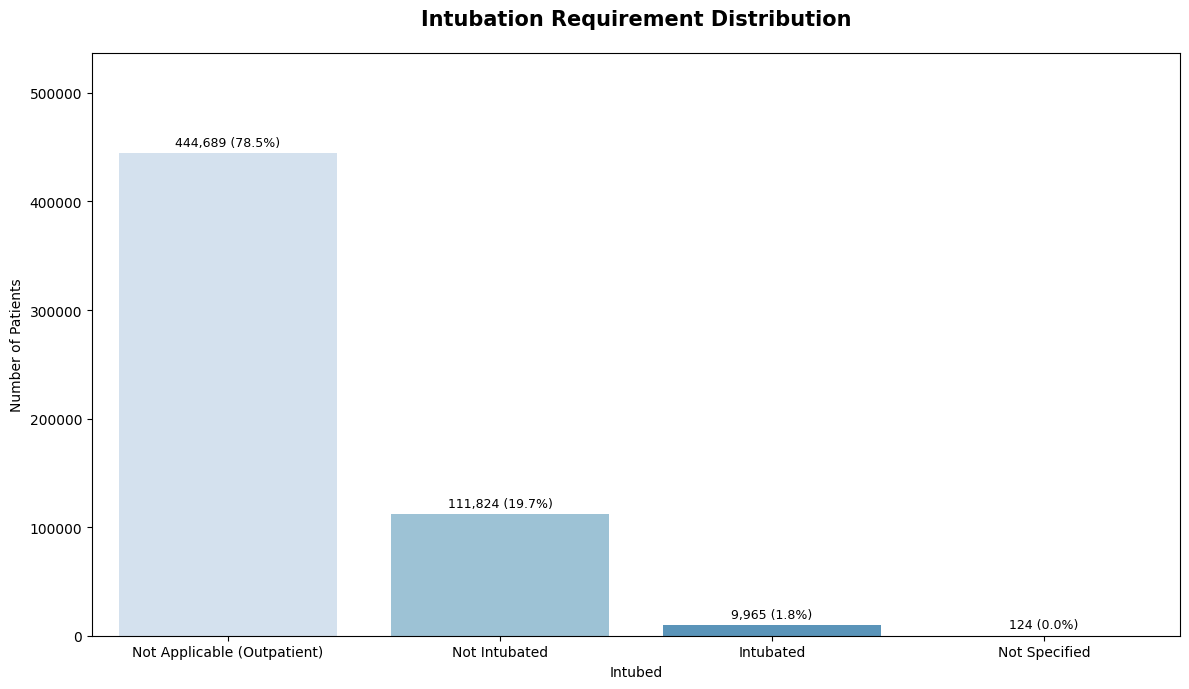


[SUMMARY TABLE: `intubed`]
                              Count Percentage (%)
intubed                                           
Not Applicable (Outpatient)  444689         78.48%
Not Intubated                111824         19.74%
Intubated                      9965          1.76%
Not Specified                   124          0.02%
------------------------------------------------------------



In [95]:
plot_categorical_distribution(df=df_stats, 
                  column='intubed', 
                  title='Intubation Requirement Distribution', 
                  mapping={
                      1: 'Intubated', 
                      0: 'Not Intubated', 
                      97: 'Not Applicable (Outpatient)', 
                      99: 'Not Specified'
                  })

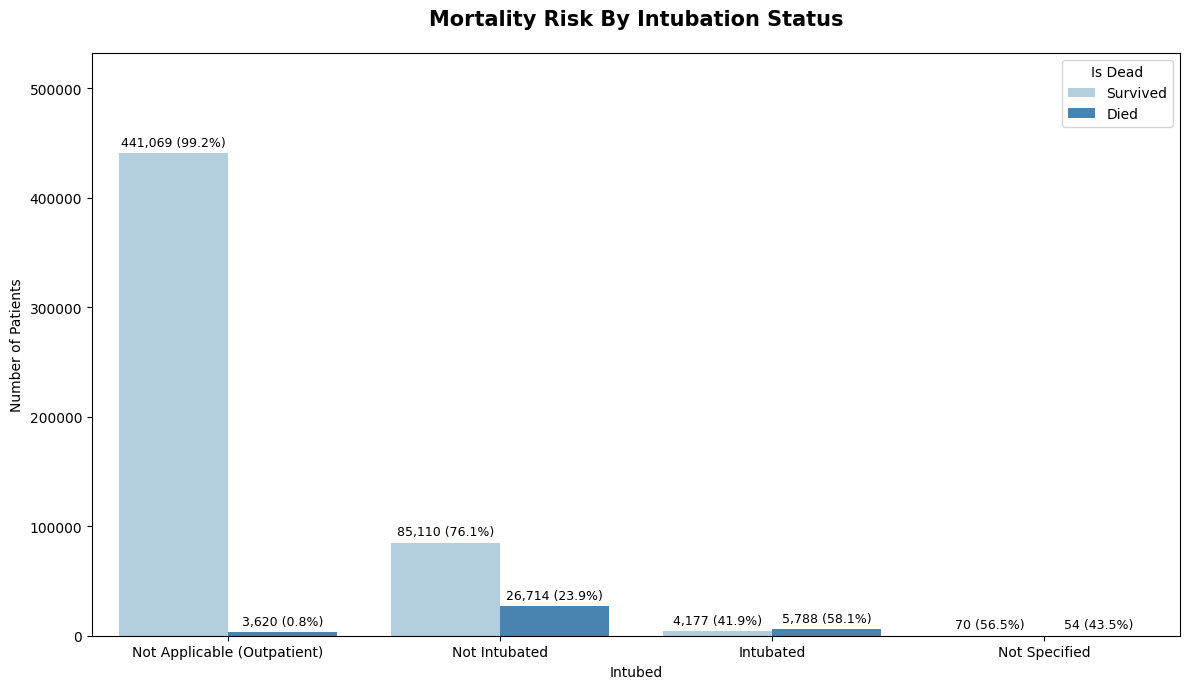


[SUMMARY TABLE: `intubed` vs `is_dead`]

1. Raw Counts:
 is_dead                       Died  Survived   Total
intubed                                             
Intubated                     5788      4177    9965
Not Applicable (Outpatient)   3620    441069  444689
Not Intubated                26714     85110  111824
Not Specified                   54        70     124
Total                        36176    530426  566602

2. Row-wise Percentage (Risk Analysis):
 is_dead                        Died Survived
intubed                                     
Intubated                    58.08%   41.92%
Not Applicable (Outpatient)   0.81%   99.19%
Not Intubated                23.89%   76.11%
Not Specified                43.55%   56.45%
------------------------------------------------------------



In [96]:
plot_categorical_distribution(df=df_stats, 
                  column='intubed', 
                  hue='is_dead', 
                  title='Mortality Risk By Intubation Status', 
                  mapping={
                      'intubed':  {1: 'Intubated', 0: 'Not Intubated', 
                                   97: 'Not Applicable (Outpatient)', 
                                   99: 'Not Specified'},
                      'is_dead': {1: 'Died', 0: 'Survived'}
                  })

#### `pneumonia`

/home/thaoly/covid-19-classification/modules/eda.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=temp, x=column, hue=hue, palette=palette)


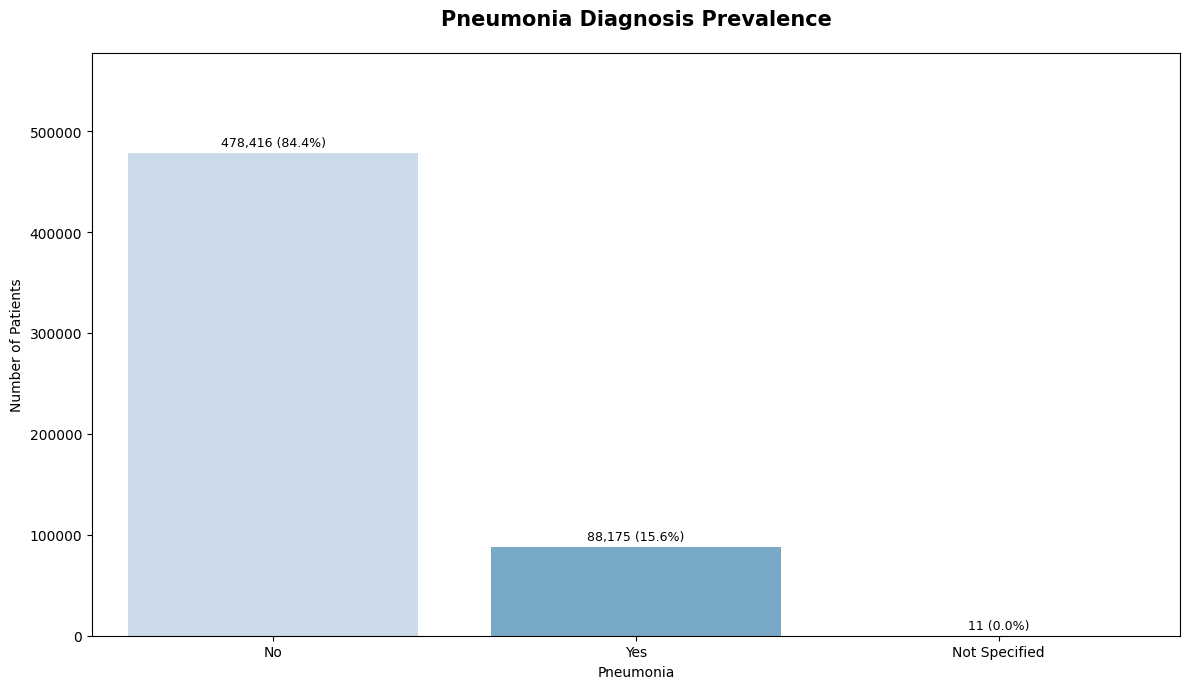


[SUMMARY TABLE: `pneumonia`]
                Count Percentage (%)
pneumonia                           
No             478416         84.44%
Yes             88175         15.56%
Not Specified      11           0.0%
------------------------------------------------------------



In [97]:
plot_categorical_distribution(df=df_stats, 
                  column='pneumonia', 
                  title='Pneumonia Diagnosis Prevalence', 
                  mapping={1: 'Yes', 0: 'No', 99: 'Not Specified'})

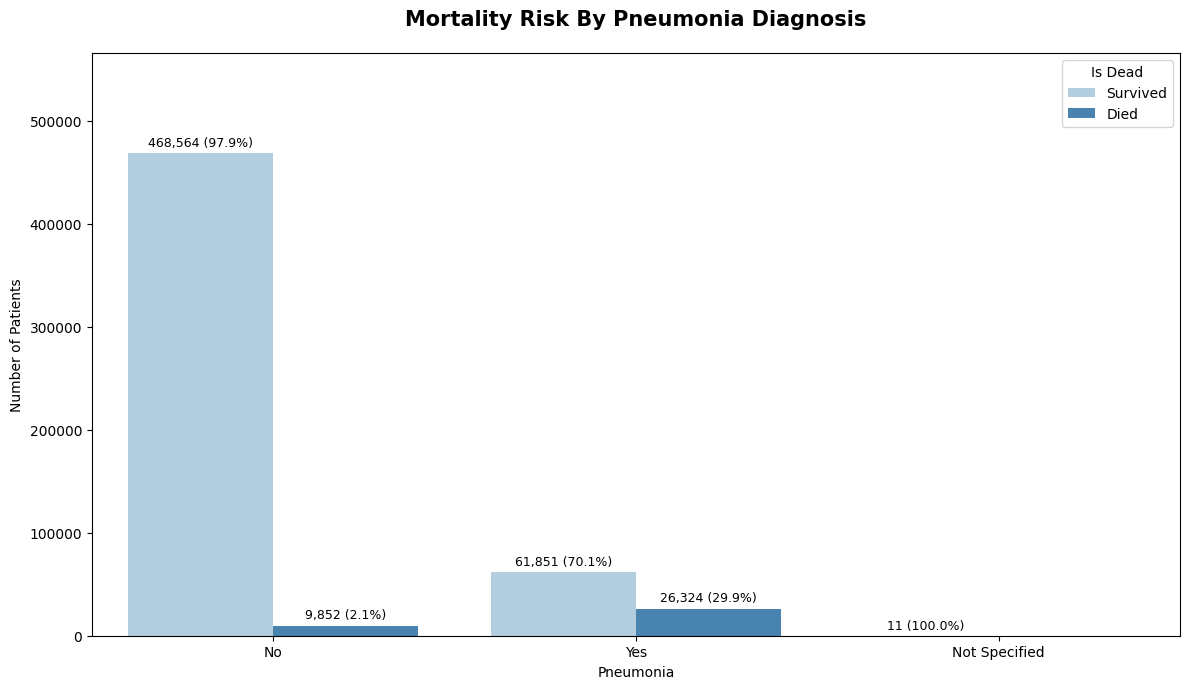


[SUMMARY TABLE: `pneumonia` vs `is_dead`]

1. Raw Counts:
 is_dead         Died  Survived   Total
pneumonia                             
No              9852    468564  478416
Not Specified      0        11      11
Yes            26324     61851   88175
Total          36176    530426  566602

2. Row-wise Percentage (Risk Analysis):
 is_dead          Died Survived
pneumonia                     
No              2.06%   97.94%
Not Specified    0.0%   100.0%
Yes            29.85%   70.15%
------------------------------------------------------------



In [98]:
plot_categorical_distribution(df=df_stats, 
                  column='pneumonia', 
                  hue='is_dead', 
                  title='Mortality Risk By Pneumonia Diagnosis', 
                  mapping={
                      'pneumonia': {1: 'Yes', 0: 'No', 99: 'Not Specified'},
                      'is_dead': {1: 'Died', 0: 'Survived'}
                  })

#### `pregnancy`

/home/thaoly/covid-19-classification/modules/eda.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=temp, x=column, hue=hue, palette=palette)


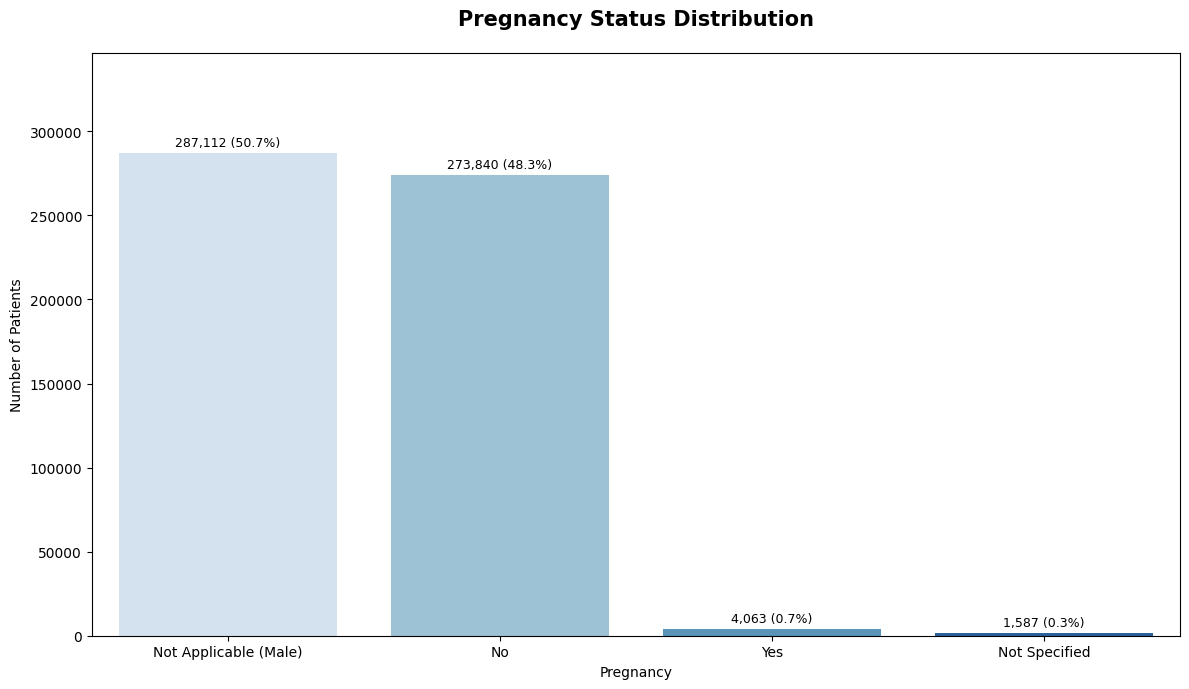


[SUMMARY TABLE: `pregnancy`]
                        Count Percentage (%)
pregnancy                                   
Not Applicable (Male)  287112         50.67%
No                     273840         48.33%
Yes                      4063          0.72%
Not Specified            1587          0.28%
------------------------------------------------------------



In [99]:
plot_categorical_distribution(df=df_stats, 
                  column='pregnancy', 
                  title='Pregnancy Status Distribution', 
                  mapping={1: 'Yes', 0: 'No', 99: 'Not Specified', 97: 'Not Applicable (Male)'})

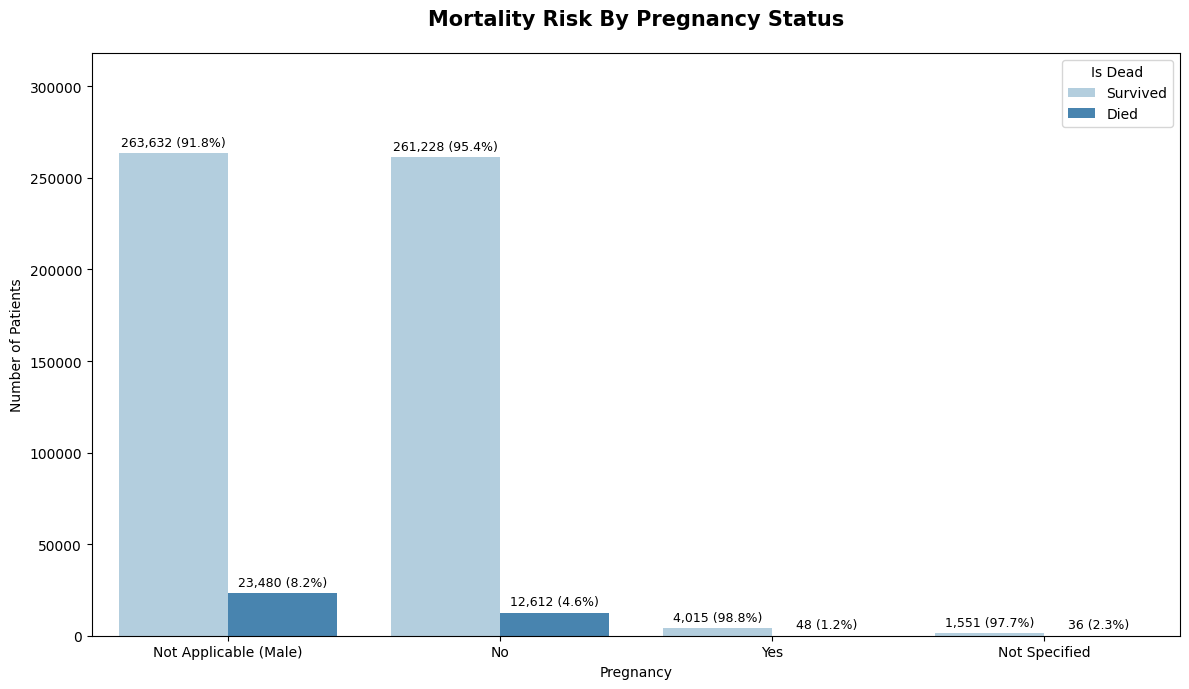


[SUMMARY TABLE: `pregnancy` vs `is_dead`]

1. Raw Counts:
 is_dead                 Died  Survived   Total
pregnancy                                     
No                     12612    261228  273840
Not Applicable (Male)  23480    263632  287112
Not Specified             36      1551    1587
Yes                       48      4015    4063
Total                  36176    530426  566602

2. Row-wise Percentage (Risk Analysis):
 is_dead                 Died Survived
pregnancy                            
No                     4.61%   95.39%
Not Applicable (Male)  8.18%   91.82%
Not Specified          2.27%   97.73%
Yes                    1.18%   98.82%
------------------------------------------------------------



In [100]:
plot_categorical_distribution(df=df_stats,
                  column='pregnancy', 
                  hue='is_dead', 
                  title='Mortality Risk By Pregnancy Status', 
                  mapping={
                      'pregnancy': {1: 'Yes', 0: 'No', 99: 'Not Specified', 97: 'Not Applicable (Male)'},
                      'is_dead': {1: 'Died', 0: 'Survived'}
                  })    

#### `diabetes`

/home/thaoly/covid-19-classification/modules/eda.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=temp, x=column, hue=hue, palette=palette)


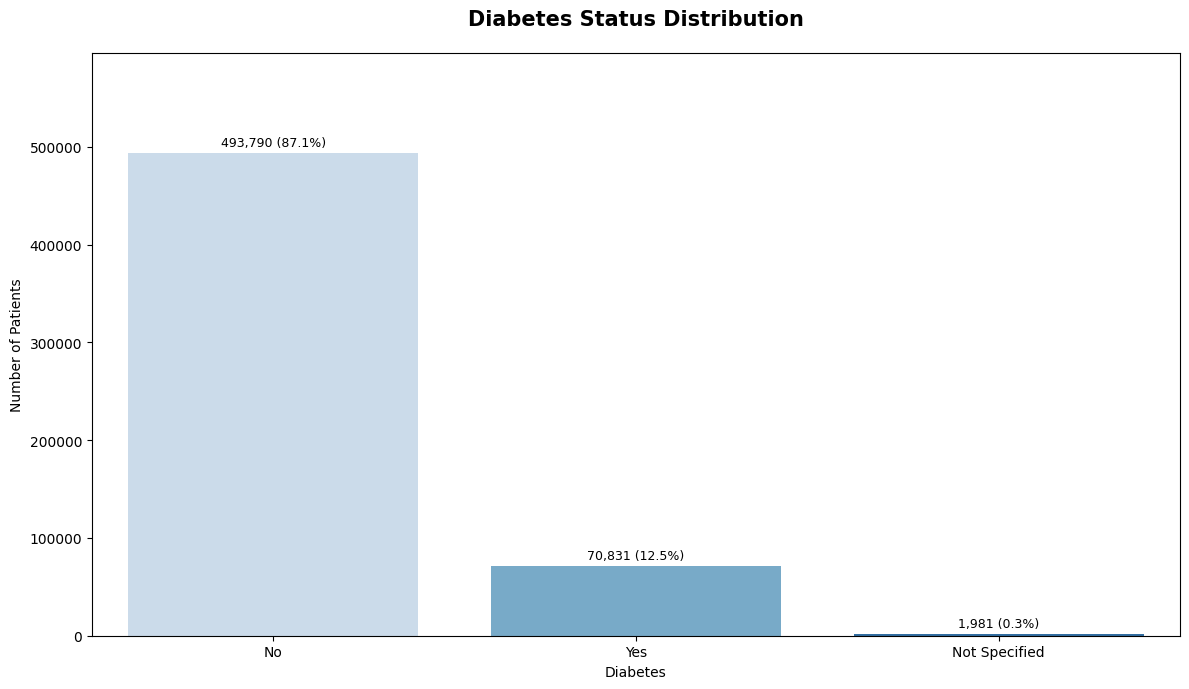


[SUMMARY TABLE: `diabetes`]
                Count Percentage (%)
diabetes                            
No             493790         87.15%
Yes             70831          12.5%
Not Specified    1981          0.35%
------------------------------------------------------------



In [101]:
plot_categorical_distribution(df=df_stats, 
                  column='diabetes',
                  title='Diabetes Status Distribution', 
                  mapping={1: 'Yes', 0: 'No', 99: 'Not Specified'})

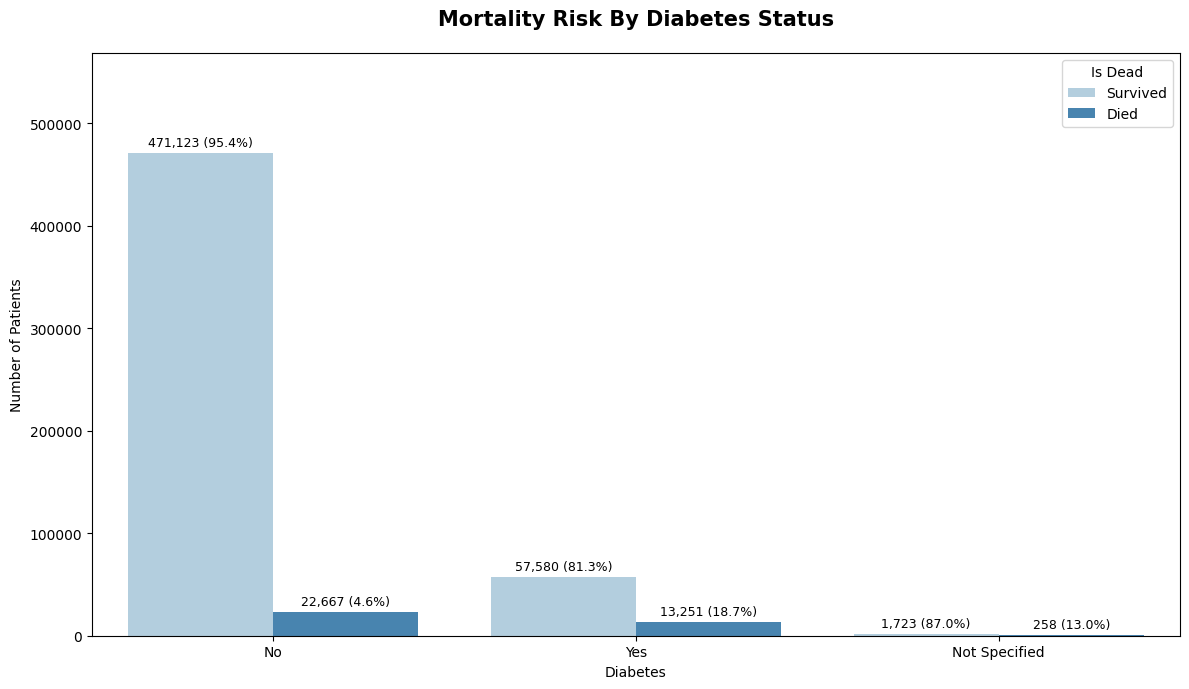


[SUMMARY TABLE: `diabetes` vs `is_dead`]

1. Raw Counts:
 is_dead         Died  Survived   Total
diabetes                              
No             22667    471123  493790
Not Specified    258      1723    1981
Yes            13251     57580   70831
Total          36176    530426  566602

2. Row-wise Percentage (Risk Analysis):
 is_dead          Died Survived
diabetes                      
No              4.59%   95.41%
Not Specified  13.02%   86.98%
Yes            18.71%   81.29%
------------------------------------------------------------



In [102]:
plot_categorical_distribution(df=df_stats,
                  column='diabetes',
                  hue='is_dead',
                  title='Mortality Risk By Diabetes Status',
                  mapping={
                      'diabetes': {1: 'Yes', 0: 'No', 99: 'Not Specified'},
                      'is_dead': {1: 'Died', 0: 'Survived'}
                  })    

### `copd`

/home/thaoly/covid-19-classification/modules/eda.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=temp, x=column, hue=hue, palette=palette)


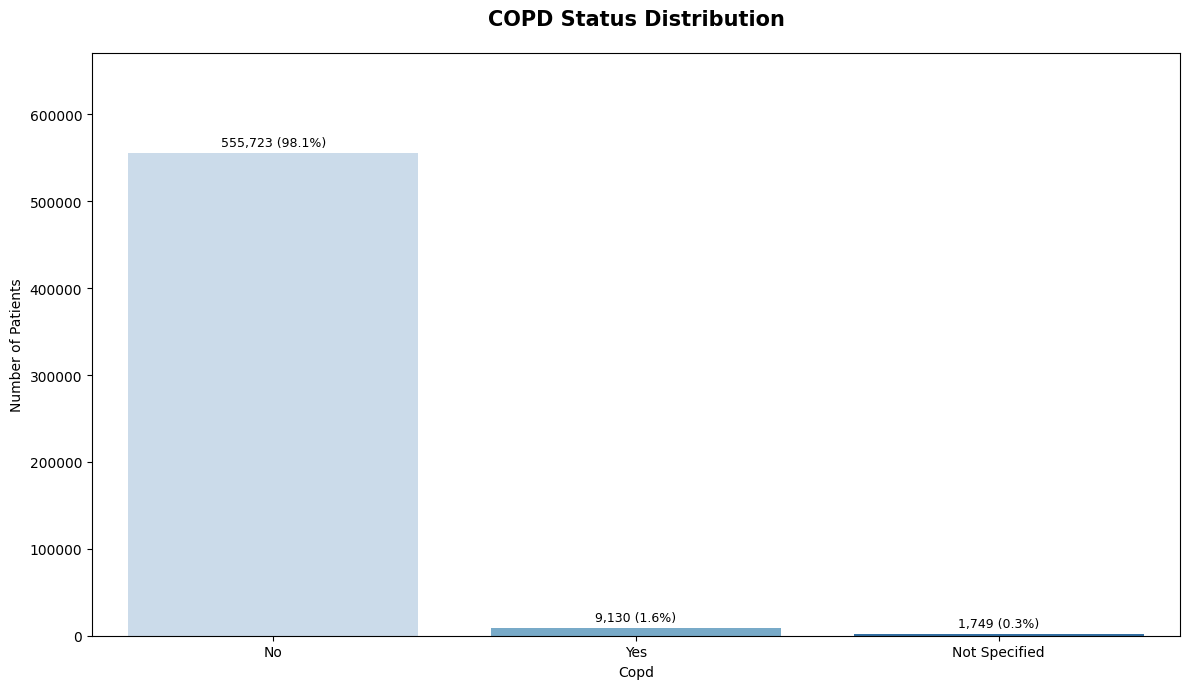


[SUMMARY TABLE: `copd`]
                Count Percentage (%)
copd                                
No             555723         98.08%
Yes              9130          1.61%
Not Specified    1749          0.31%
------------------------------------------------------------



In [103]:
plot_categorical_distribution(df=df_stats, 
                  column='copd',
                  title='COPD Status Distribution',
                  mapping={1: 'Yes', 0: 'No', 99: 'Not Specified'})


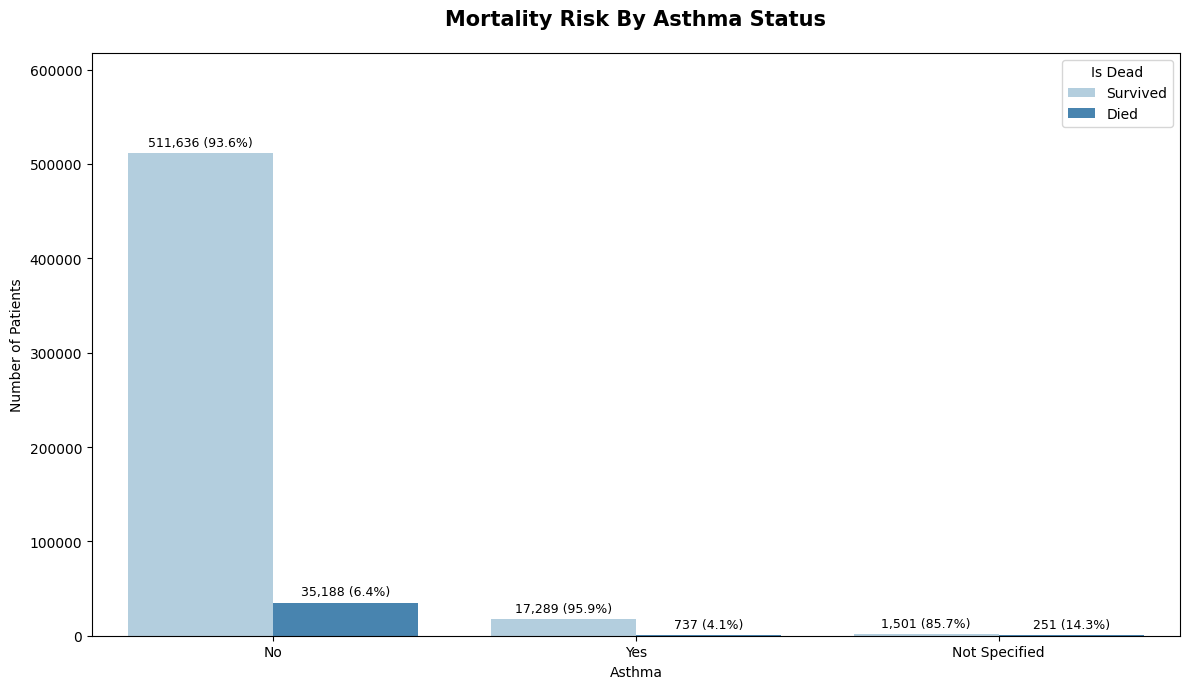


[SUMMARY TABLE: `asthma` vs `is_dead`]

1. Raw Counts:
 is_dead         Died  Survived   Total
asthma                                
No             35188    511636  546824
Not Specified    251      1501    1752
Yes              737     17289   18026
Total          36176    530426  566602

2. Row-wise Percentage (Risk Analysis):
 is_dead          Died Survived
asthma                        
No              6.43%   93.57%
Not Specified  14.33%   85.67%
Yes             4.09%   95.91%
------------------------------------------------------------



In [104]:
plot_categorical_distribution(df=df_stats,
                  column='asthma',
                  hue='is_dead',
                  title='Mortality Risk By Asthma Status',
                  mapping={
                      'asthma': {1: 'Yes', 0: 'No', 99: 'Not Specified'},
                      'is_dead': {1: 'Died', 0: 'Survived'}
                  })    

#### `inmsupr`

/home/thaoly/covid-19-classification/modules/eda.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=temp, x=column, hue=hue, palette=palette)


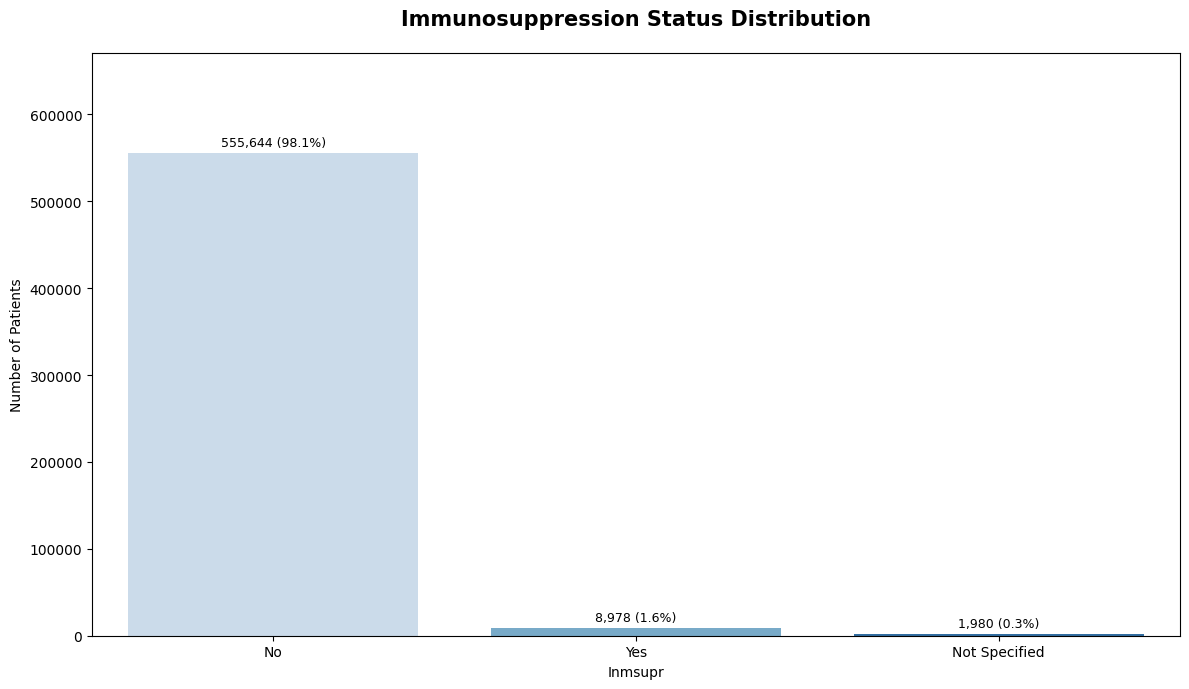


[SUMMARY TABLE: `inmsupr`]
                Count Percentage (%)
inmsupr                             
No             555644         98.07%
Yes              8978          1.58%
Not Specified    1980          0.35%
------------------------------------------------------------



In [105]:
plot_categorical_distribution(df=df_stats, 
                  column='inmsupr',
                  title='Immunosuppression Status Distribution',
                  mapping={1: 'Yes', 0: 'No', 99: 'Not Specified'})


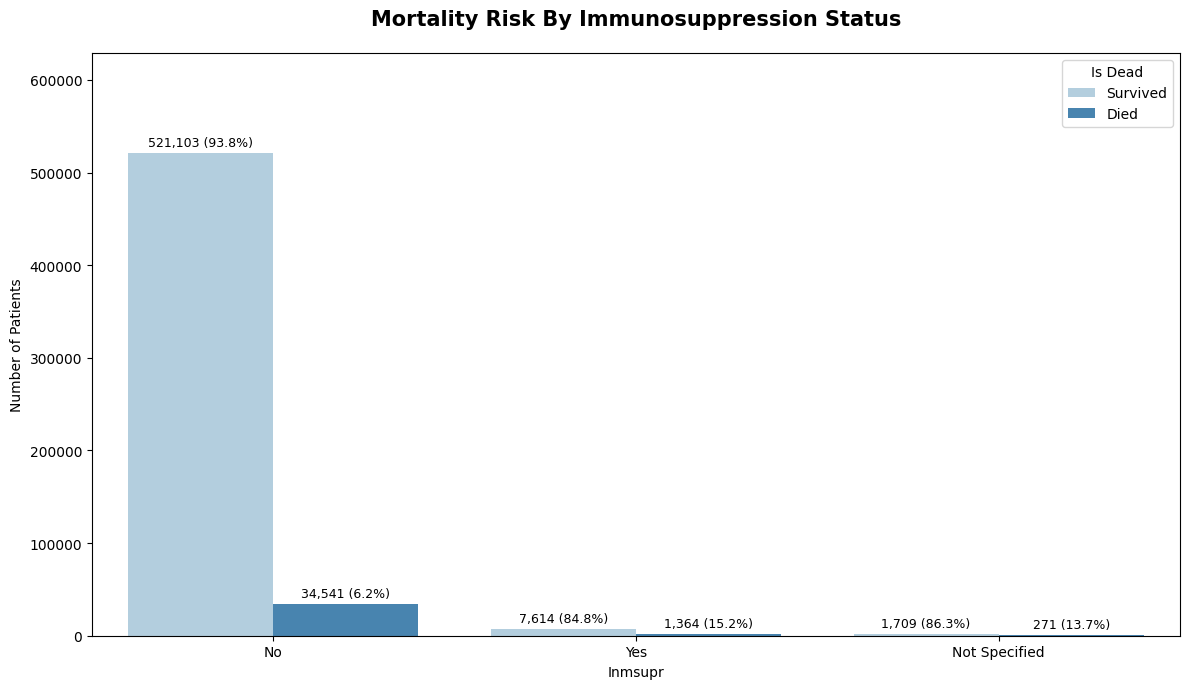


[SUMMARY TABLE: `inmsupr` vs `is_dead`]

1. Raw Counts:
 is_dead         Died  Survived   Total
inmsupr                               
No             34541    521103  555644
Not Specified    271      1709    1980
Yes             1364      7614    8978
Total          36176    530426  566602

2. Row-wise Percentage (Risk Analysis):
 is_dead          Died Survived
inmsupr                       
No              6.22%   93.78%
Not Specified  13.69%   86.31%
Yes            15.19%   84.81%
------------------------------------------------------------



In [106]:
plot_categorical_distribution(df=df_stats,
                  column='inmsupr',
                  hue='is_dead',
                  title='Mortality Risk By Immunosuppression Status',
                  mapping={
                      'inmsupr': {1: 'Yes', 0: 'No', 99: 'Not Specified'},
                      'is_dead': {1: 'Died', 0: 'Survived'}
                  })

### `hypertension`

/home/thaoly/covid-19-classification/modules/eda.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=temp, x=column, hue=hue, palette=palette)


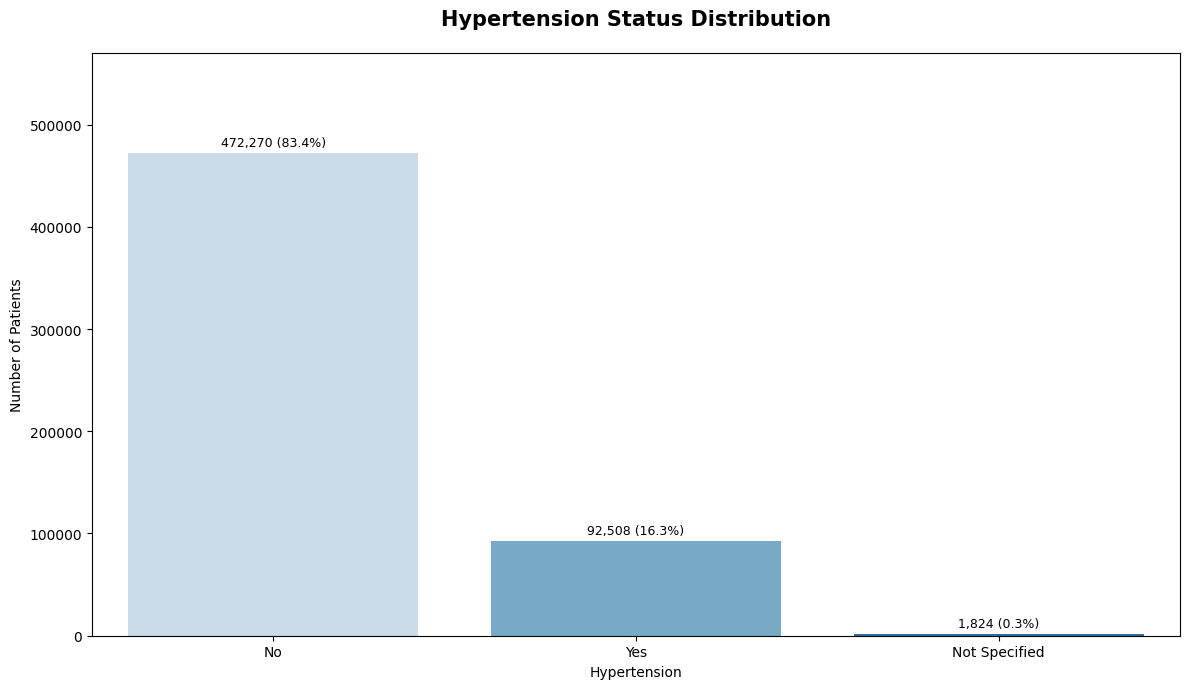


[SUMMARY TABLE: `hypertension`]
                Count Percentage (%)
hypertension                        
No             472270         83.35%
Yes             92508         16.33%
Not Specified    1824          0.32%
------------------------------------------------------------



In [107]:
plot_categorical_distribution(df=df_stats,
                  column='hypertension',
                    title='Hypertension Status Distribution',
                    mapping={1: 'Yes', 0: 'No', 99: 'Not Specified'})


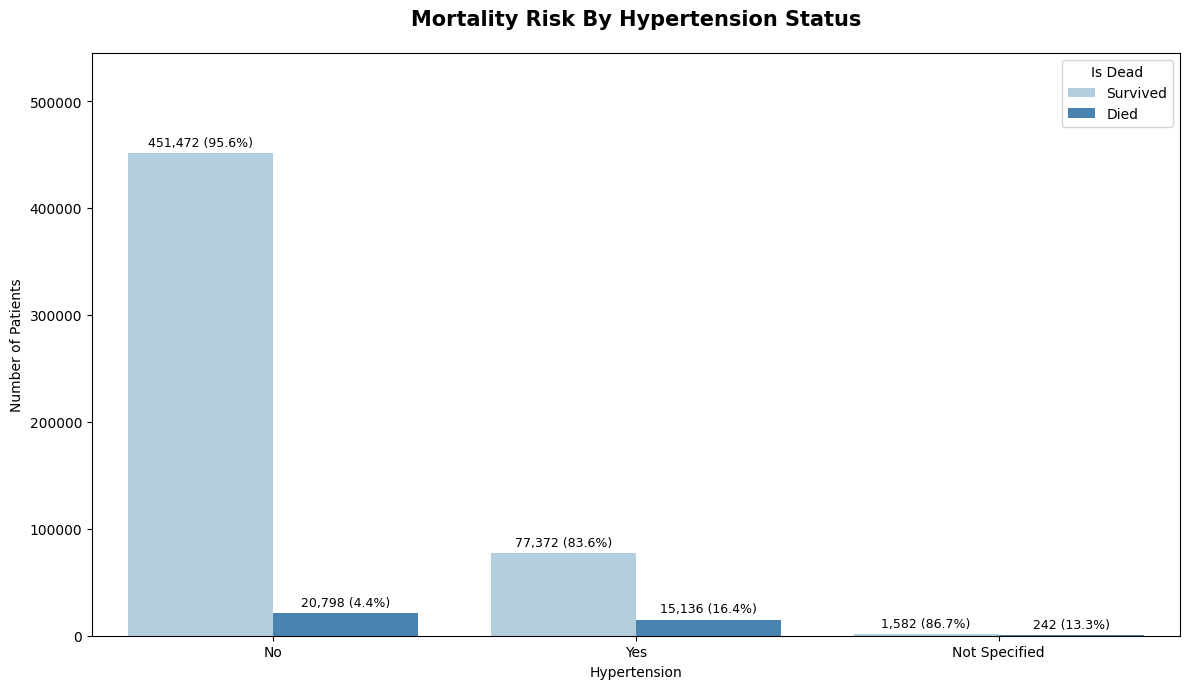


[SUMMARY TABLE: `hypertension` vs `is_dead`]

1. Raw Counts:
 is_dead         Died  Survived   Total
hypertension                          
No             20798    451472  472270
Not Specified    242      1582    1824
Yes            15136     77372   92508
Total          36176    530426  566602

2. Row-wise Percentage (Risk Analysis):
 is_dead          Died Survived
hypertension                  
No               4.4%    95.6%
Not Specified  13.27%   86.73%
Yes            16.36%   83.64%
------------------------------------------------------------



In [108]:
plot_categorical_distribution(df=df_stats,
                  column='hypertension',
                  hue='is_dead',
                  title='Mortality Risk By Hypertension Status',
                  mapping={
                      'hypertension': {1: 'Yes', 0: 'No', 99: 'Not Specified'},
                      'is_dead': {1: 'Died', 0: 'Survived'}
                  })

#### `other_disease`

/home/thaoly/covid-19-classification/modules/eda.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=temp, x=column, hue=hue, palette=palette)


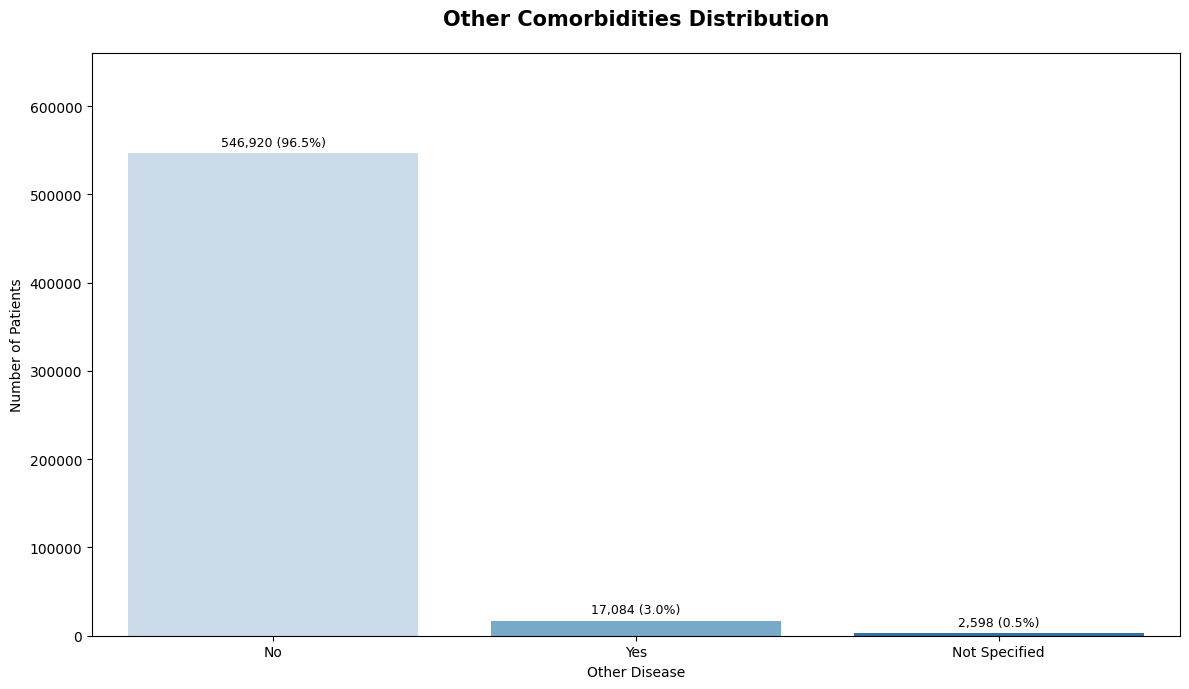


[SUMMARY TABLE: `other_disease`]
                Count Percentage (%)
other_disease                       
No             546920         96.53%
Yes             17084          3.02%
Not Specified    2598          0.46%
------------------------------------------------------------



In [109]:
plot_categorical_distribution(df=df_stats,
                  column='other_disease',
                  title='Other Comorbidities Distribution',
                  mapping={1: 'Yes', 0: 'No', 99: 'Not Specified'})


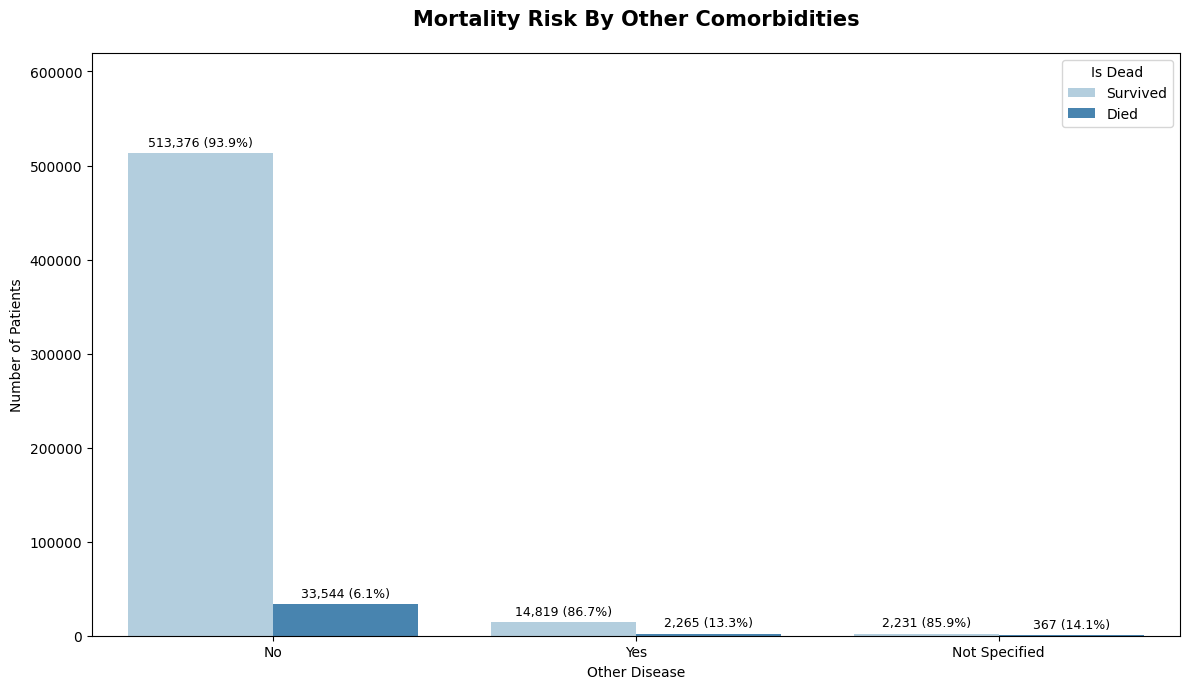


[SUMMARY TABLE: `other_disease` vs `is_dead`]

1. Raw Counts:
 is_dead         Died  Survived   Total
other_disease                         
No             33544    513376  546920
Not Specified    367      2231    2598
Yes             2265     14819   17084
Total          36176    530426  566602

2. Row-wise Percentage (Risk Analysis):
 is_dead          Died Survived
other_disease                 
No              6.13%   93.87%
Not Specified  14.13%   85.87%
Yes            13.26%   86.74%
------------------------------------------------------------



In [110]:
plot_categorical_distribution(df=df_stats,
                  column='other_disease',
                  hue='is_dead',
                  title='Mortality Risk By Other Comorbidities',
                  mapping={
                      'other_disease': {1: 'Yes', 0: 'No', 99: 'Not Specified'},
                      'is_dead': {1: 'Died', 0: 'Survived'}
                  })

#### `cardiovascular`

/home/thaoly/covid-19-classification/modules/eda.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=temp, x=column, hue=hue, palette=palette)


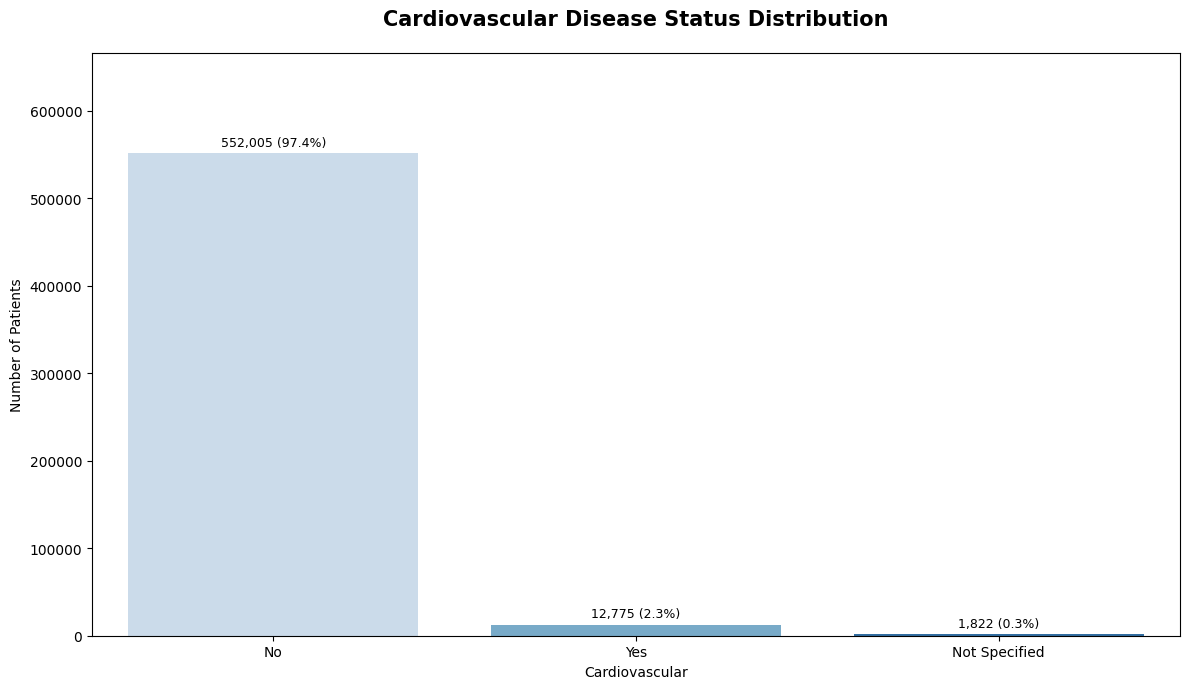


[SUMMARY TABLE: `cardiovascular`]
                 Count Percentage (%)
cardiovascular                       
No              552005         97.42%
Yes              12775          2.25%
Not Specified     1822          0.32%
------------------------------------------------------------



In [111]:
plot_categorical_distribution(df=df_stats,
                  column='cardiovascular',
                    title='Cardiovascular Disease Status Distribution',
                    mapping={1: 'Yes', 0: 'No', 99: 'Not Specified'})

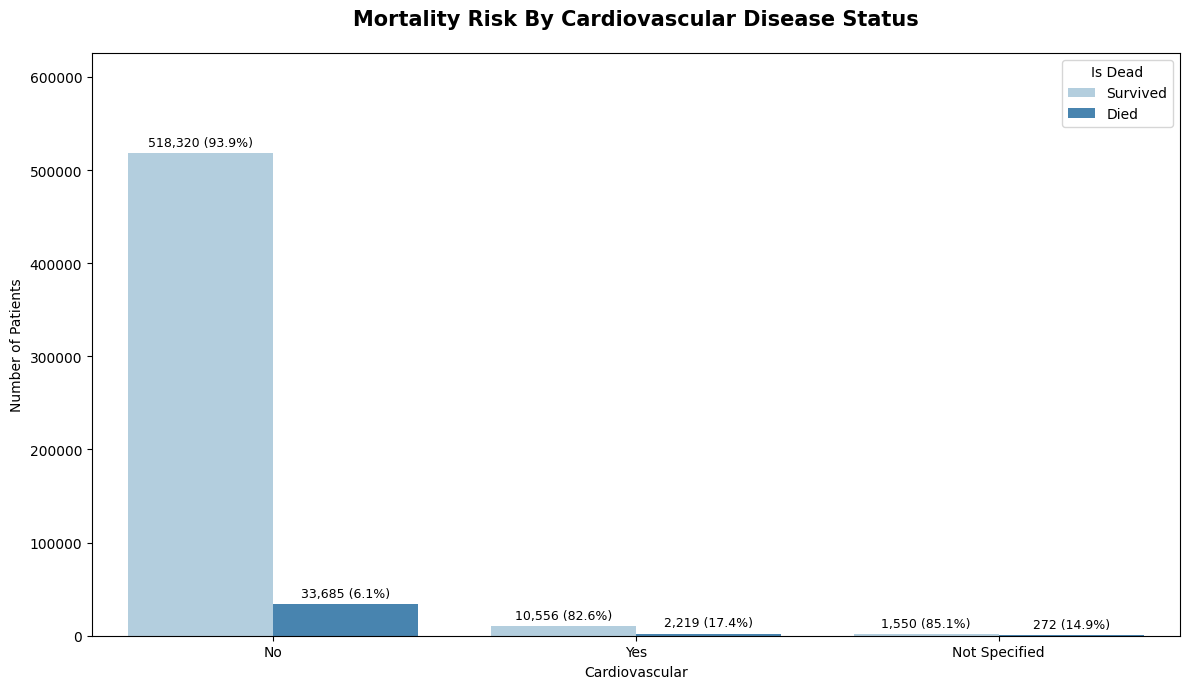


[SUMMARY TABLE: `cardiovascular` vs `is_dead`]

1. Raw Counts:
 is_dead          Died  Survived   Total
cardiovascular                         
No              33685    518320  552005
Not Specified     272      1550    1822
Yes              2219     10556   12775
Total           36176    530426  566602

2. Row-wise Percentage (Risk Analysis):
 is_dead           Died Survived
cardiovascular                 
No                6.1%    93.9%
Not Specified   14.93%   85.07%
Yes             17.37%   82.63%
------------------------------------------------------------



In [112]:
plot_categorical_distribution(df=df_stats, 
                  column='cardiovascular', 
                  hue='is_dead', 
                  title='Mortality Risk By Cardiovascular Disease Status', 
                  mapping={
                        'cardiovascular': {1: 'Yes', 0: 'No', 99: 'Not Specified'},
                        'is_dead': {1: 'Died', 0: 'Survived'}
                  })

#### `obesity`

/home/thaoly/covid-19-classification/modules/eda.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=temp, x=column, hue=hue, palette=palette)


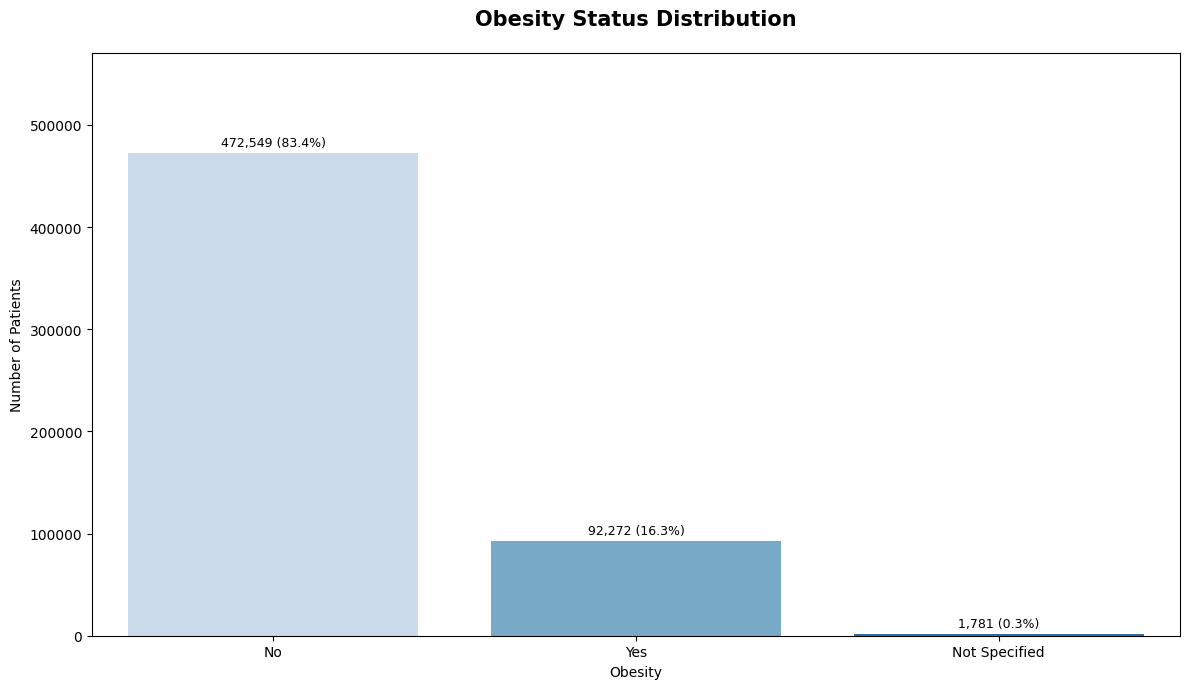


[SUMMARY TABLE: `obesity`]
                Count Percentage (%)
obesity                             
No             472549          83.4%
Yes             92272         16.29%
Not Specified    1781          0.31%
------------------------------------------------------------



In [113]:
plot_categorical_distribution(df=df_stats,
                  column='obesity',
                  title='Obesity Status Distribution',
                  mapping={1: 'Yes', 0: 'No', 99: 'Not Specified'})

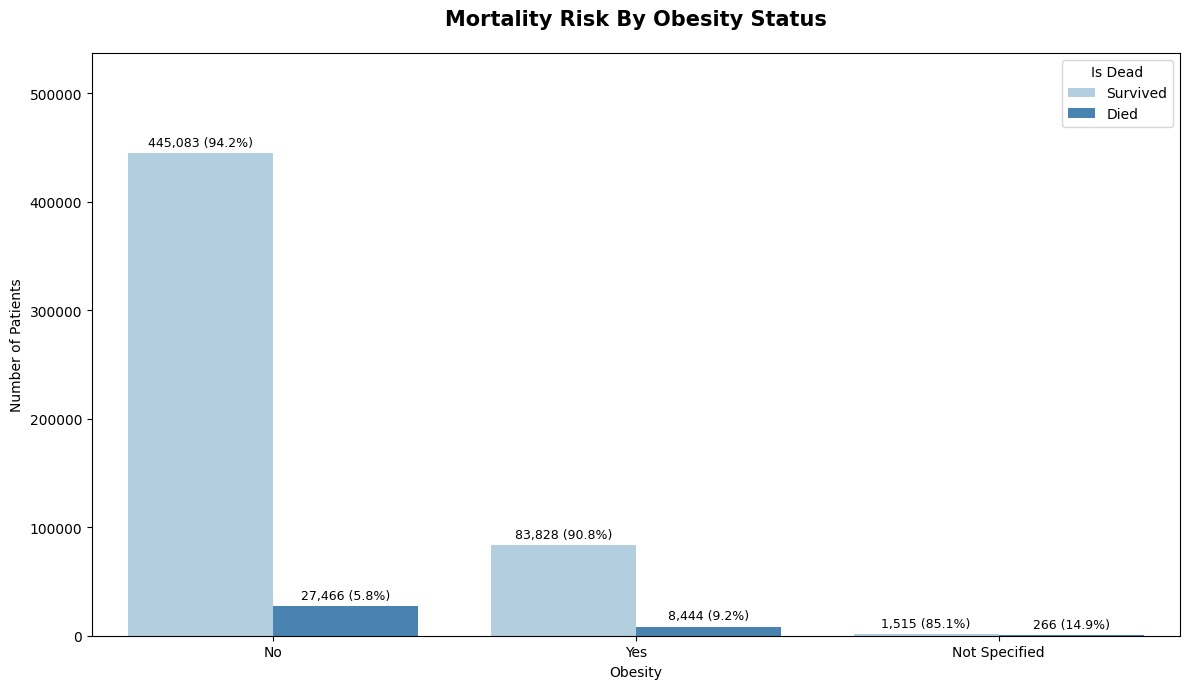


[SUMMARY TABLE: `obesity` vs `is_dead`]

1. Raw Counts:
 is_dead         Died  Survived   Total
obesity                               
No             27466    445083  472549
Not Specified    266      1515    1781
Yes             8444     83828   92272
Total          36176    530426  566602

2. Row-wise Percentage (Risk Analysis):
 is_dead          Died Survived
obesity                       
No              5.81%   94.19%
Not Specified  14.94%   85.06%
Yes             9.15%   90.85%
------------------------------------------------------------



In [114]:
plot_categorical_distribution(df=df_stats, 
                  column='obesity', 
                  hue='is_dead', 
                  title='Mortality Risk By Obesity Status', 
                  mapping={
                      'obesity': {1: 'Yes', 0: 'No', 99: 'Not Specified'},
                      'is_dead': {1: 'Died', 0: 'Survived'}
                  })

#### `renal_chronic`

/home/thaoly/covid-19-classification/modules/eda.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=temp, x=column, hue=hue, palette=palette)


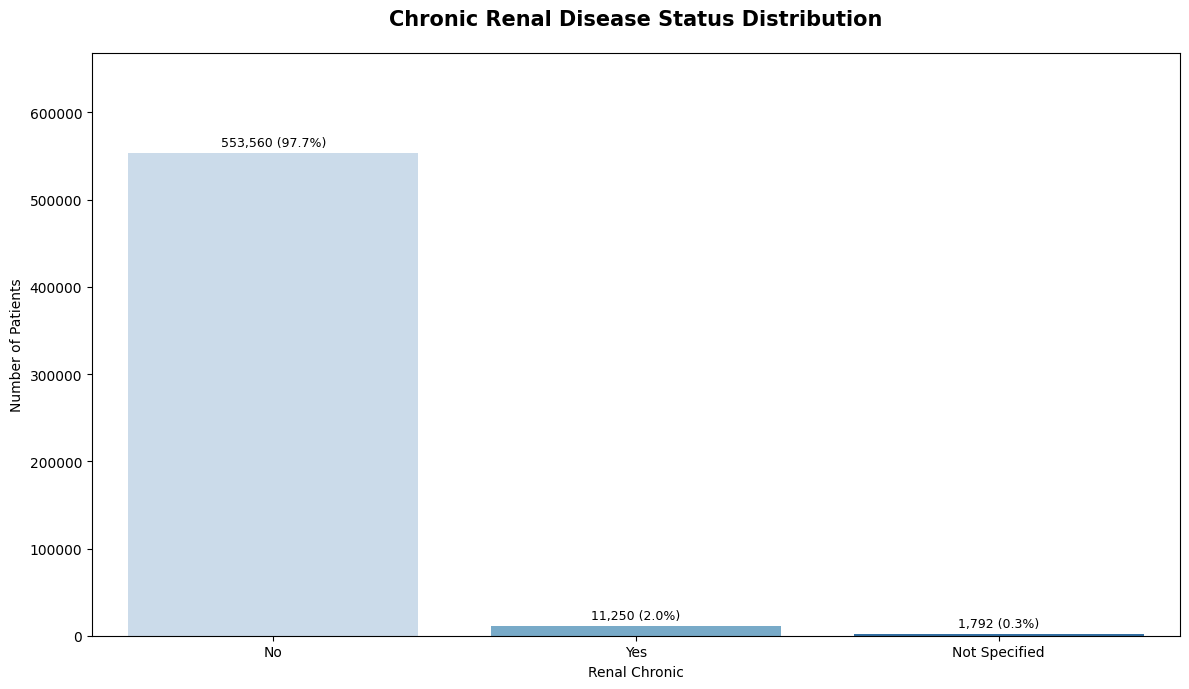


[SUMMARY TABLE: `renal_chronic`]
                Count Percentage (%)
renal_chronic                       
No             553560          97.7%
Yes             11250          1.99%
Not Specified    1792          0.32%
------------------------------------------------------------



In [115]:
plot_categorical_distribution(df=df_stats,
                    column='renal_chronic',
                    title='Chronic Renal Disease Status Distribution',
                    mapping={1: 'Yes', 0: 'No', 99: 'Not Specified'})

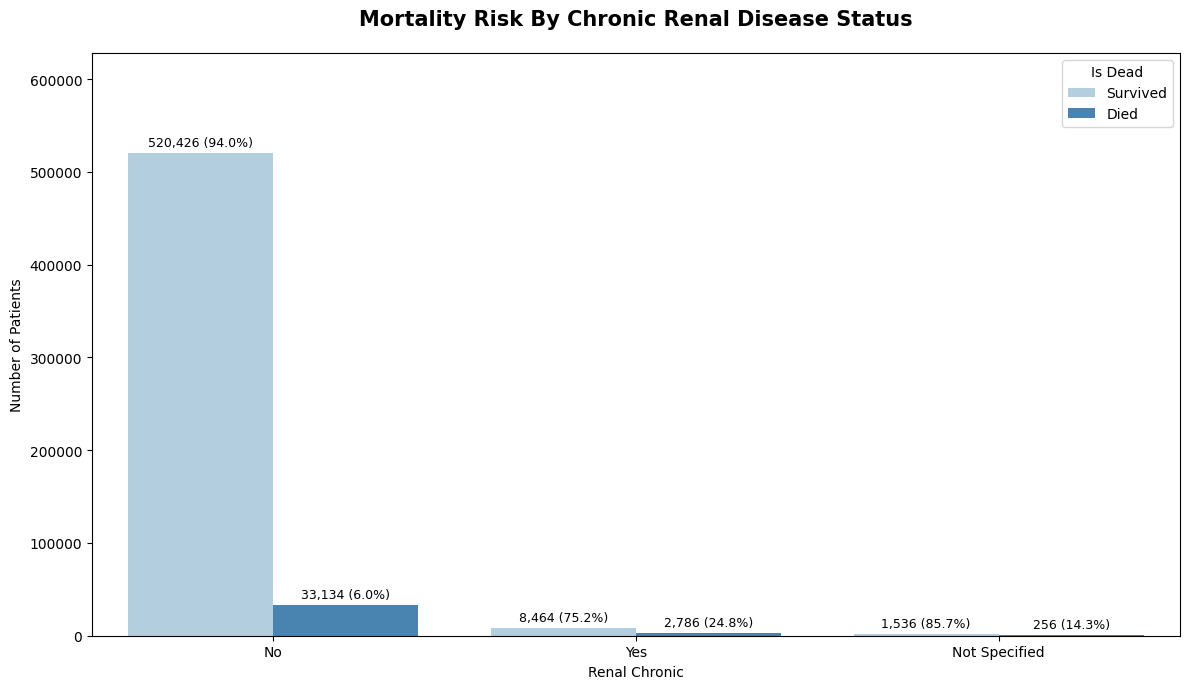


[SUMMARY TABLE: `renal_chronic` vs `is_dead`]

1. Raw Counts:
 is_dead         Died  Survived   Total
renal_chronic                         
No             33134    520426  553560
Not Specified    256      1536    1792
Yes             2786      8464   11250
Total          36176    530426  566602

2. Row-wise Percentage (Risk Analysis):
 is_dead          Died Survived
renal_chronic                 
No              5.99%   94.01%
Not Specified  14.29%   85.71%
Yes            24.76%   75.24%
------------------------------------------------------------



In [116]:
plot_categorical_distribution(df=df_stats,
                  column='renal_chronic',
                  hue='is_dead',
                  title='Mortality Risk By Chronic Renal Disease Status',
                  mapping={
                      'renal_chronic': {1: 'Yes', 0: 'No', 99: 'Not Specified'},
                      'is_dead': {1: 'Died', 0: 'Survived'}
                  })

#### `tobacco`

/home/thaoly/covid-19-classification/modules/eda.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=temp, x=column, hue=hue, palette=palette)


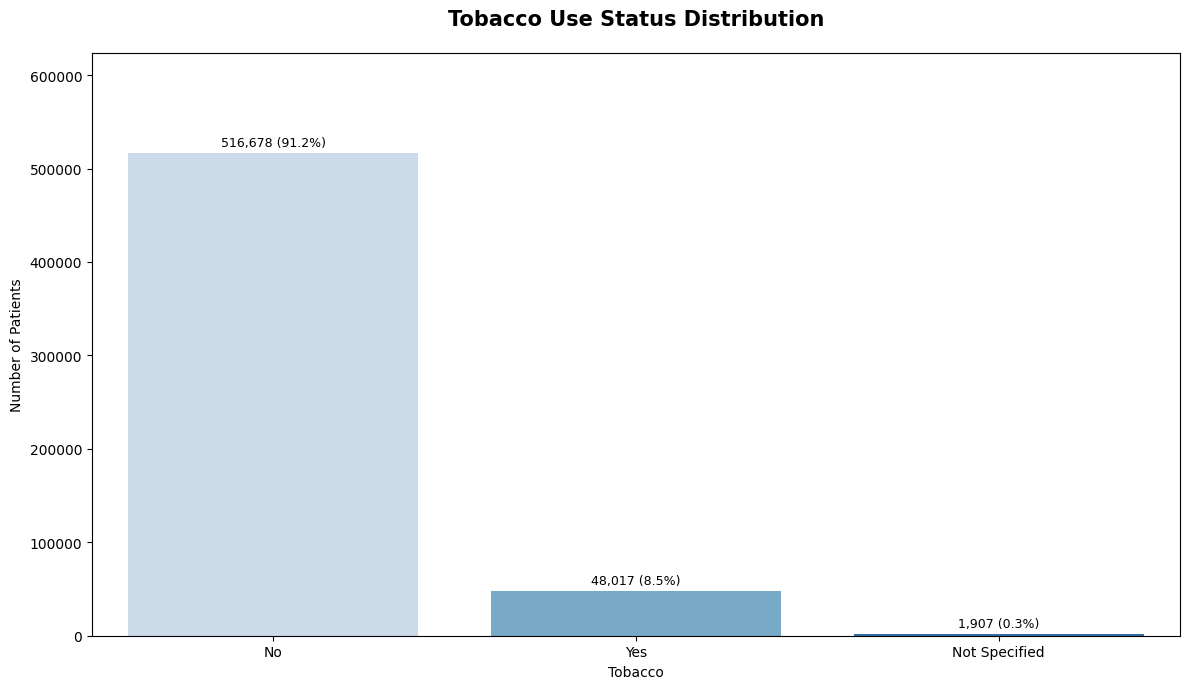


[SUMMARY TABLE: `tobacco`]
                Count Percentage (%)
tobacco                             
No             516678         91.19%
Yes             48017          8.47%
Not Specified    1907          0.34%
------------------------------------------------------------



In [117]:
plot_categorical_distribution(df=df_stats,
                  column='tobacco',
                  title='Tobacco Use Status Distribution',
                  mapping={1: 'Yes', 0: 'No', 99: 'Not Specified'})

#### `contact_other_covid`

/home/thaoly/covid-19-classification/modules/eda.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=temp, x=column, hue=hue, palette=palette)


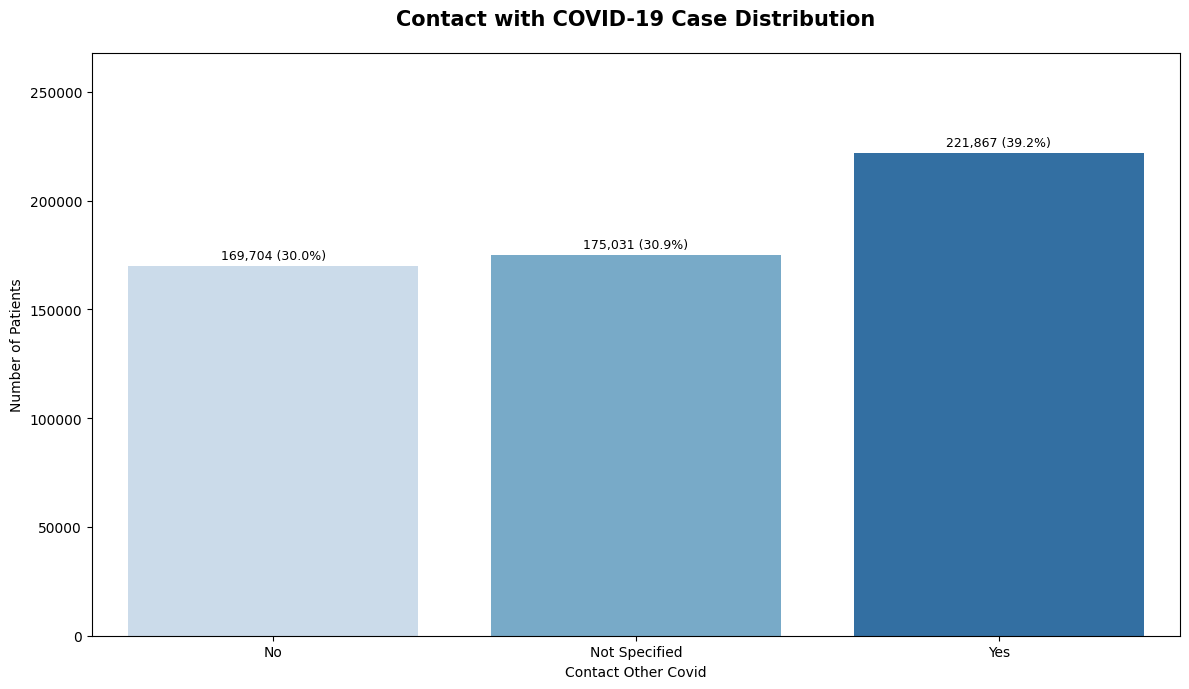


[SUMMARY TABLE: `contact_other_covid`]
                      Count Percentage (%)
contact_other_covid                       
Yes                  221867         39.16%
Not Specified        175031         30.89%
No                   169704         29.95%
------------------------------------------------------------



In [118]:
plot_categorical_distribution(df=df_stats,
                  column='contact_other_covid',
                    title='Contact with COVID-19 Case Distribution',
                    mapping={1: 'Yes', 0: 'No', 99: 'Not Specified'})

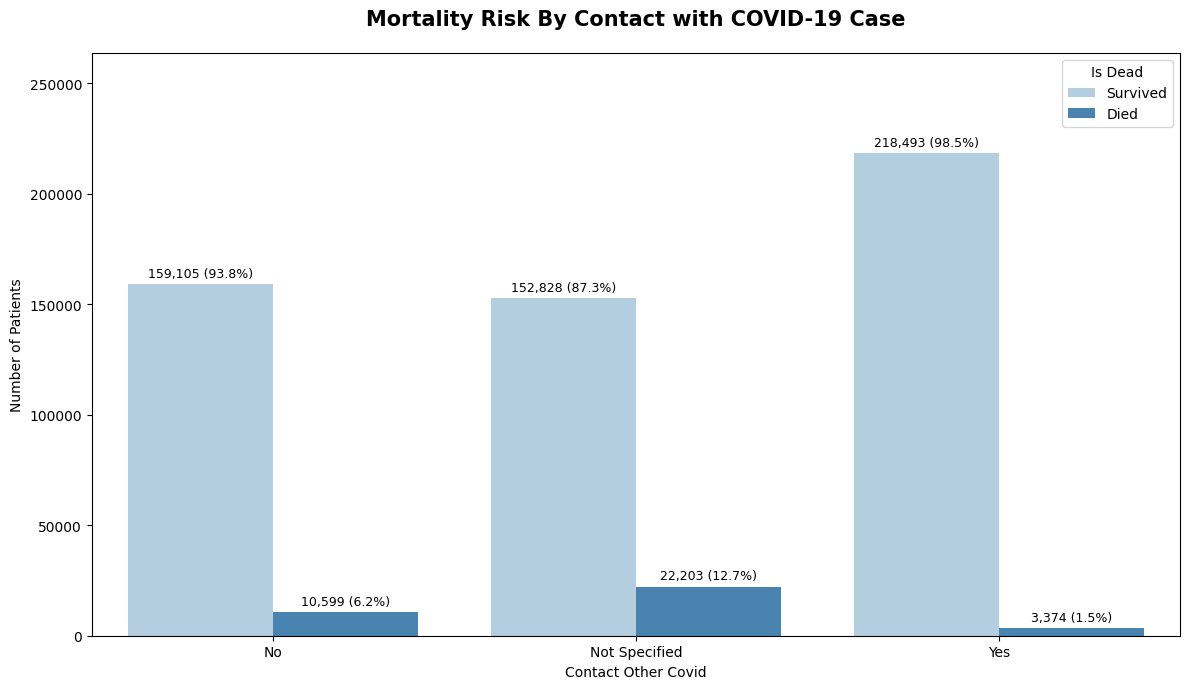


[SUMMARY TABLE: `contact_other_covid` vs `is_dead`]

1. Raw Counts:
 is_dead               Died  Survived   Total
contact_other_covid                         
No                   10599    159105  169704
Not Specified        22203    152828  175031
Yes                   3374    218493  221867
Total                36176    530426  566602

2. Row-wise Percentage (Risk Analysis):
 is_dead                Died Survived
contact_other_covid                 
No                    6.25%   93.75%
Not Specified        12.69%   87.31%
Yes                   1.52%   98.48%
------------------------------------------------------------



In [119]:
plot_categorical_distribution(df=df_stats,
                  column='contact_other_covid',
                  hue='is_dead',
                  title='Mortality Risk By Contact with COVID-19 Case',
                  mapping={
                      'contact_other_covid': {1: 'Yes', 0: 'No', 99: 'Not Specified'},
                      'is_dead': {1: 'Died', 0: 'Survived'}
                  })

#### `covid_res`

/home/thaoly/covid-19-classification/modules/eda.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=temp, x=column, hue=hue, palette=palette)


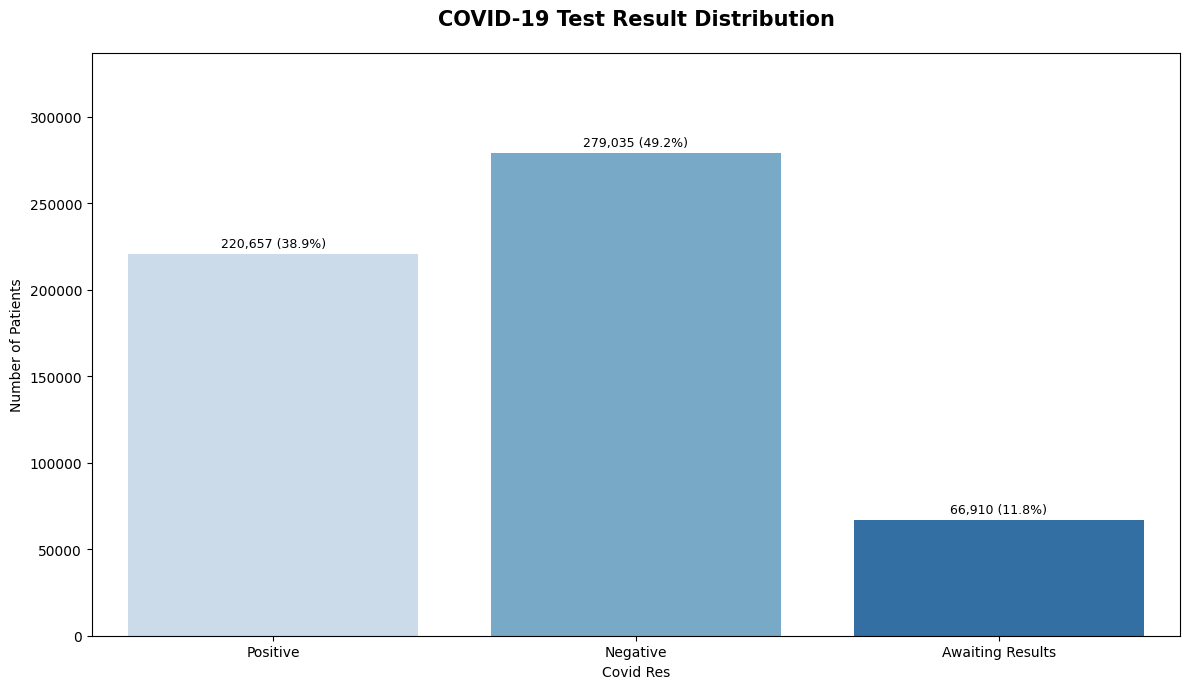


[SUMMARY TABLE: `covid_res`]
                   Count Percentage (%)
covid_res                              
Negative          279035         49.25%
Positive          220657         38.94%
Awaiting Results   66910         11.81%
------------------------------------------------------------



In [120]:
plot_categorical_distribution(df=df_stats,
                  column='covid_res',
                    title='COVID-19 Test Result Distribution',
                    mapping={1: 'Positive', 2: 'Negative', 3: 'Awaiting Results'})

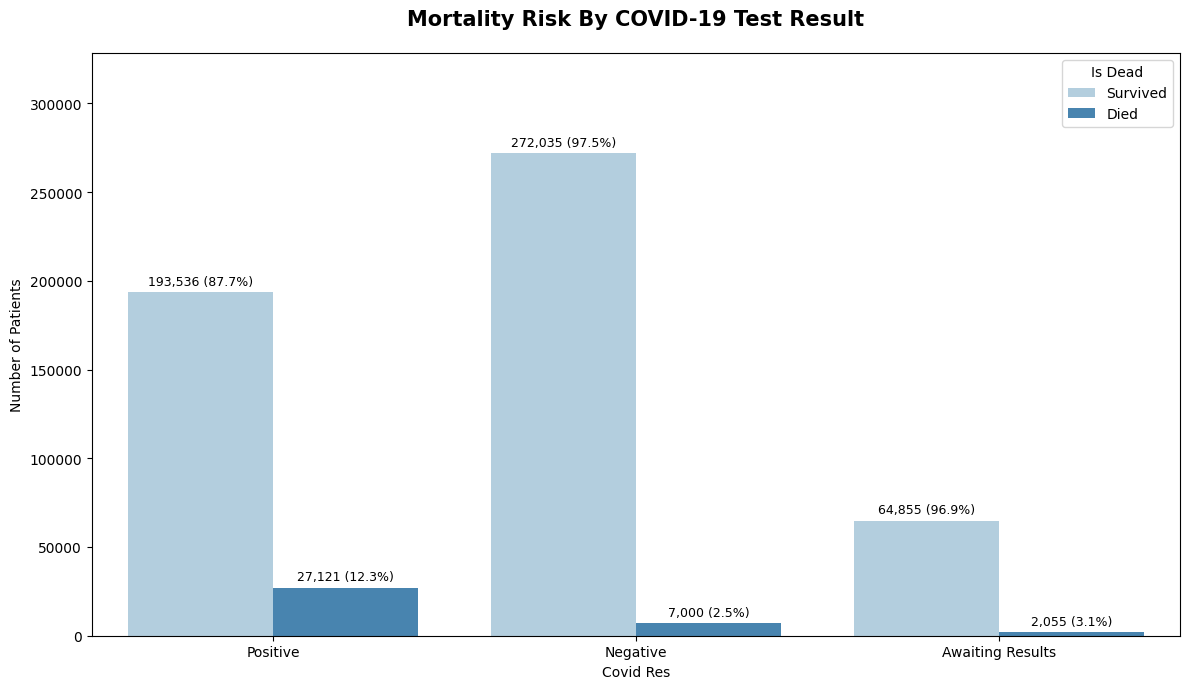


[SUMMARY TABLE: `covid_res` vs `is_dead`]

1. Raw Counts:
 is_dead            Died  Survived   Total
covid_res                                
Awaiting Results   2055     64855   66910
Negative           7000    272035  279035
Positive          27121    193536  220657
Total             36176    530426  566602

2. Row-wise Percentage (Risk Analysis):
 is_dead             Died Survived
covid_res                        
Awaiting Results   3.07%   96.93%
Negative           2.51%   97.49%
Positive          12.29%   87.71%
------------------------------------------------------------



In [121]:
plot_categorical_distribution(df=df_stats,
                  column='covid_res',
                  hue='is_dead',
                  title='Mortality Risk By COVID-19 Test Result',
                  mapping={
                      'covid_res': {1: 'Positive', 2: 'Negative', 3: 'Awaiting Results'},
                      'is_dead': {1: 'Died', 0: 'Survived'}
                  })

#### `icu`

/home/thaoly/covid-19-classification/modules/eda.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=temp, x=column, hue=hue, palette=palette)


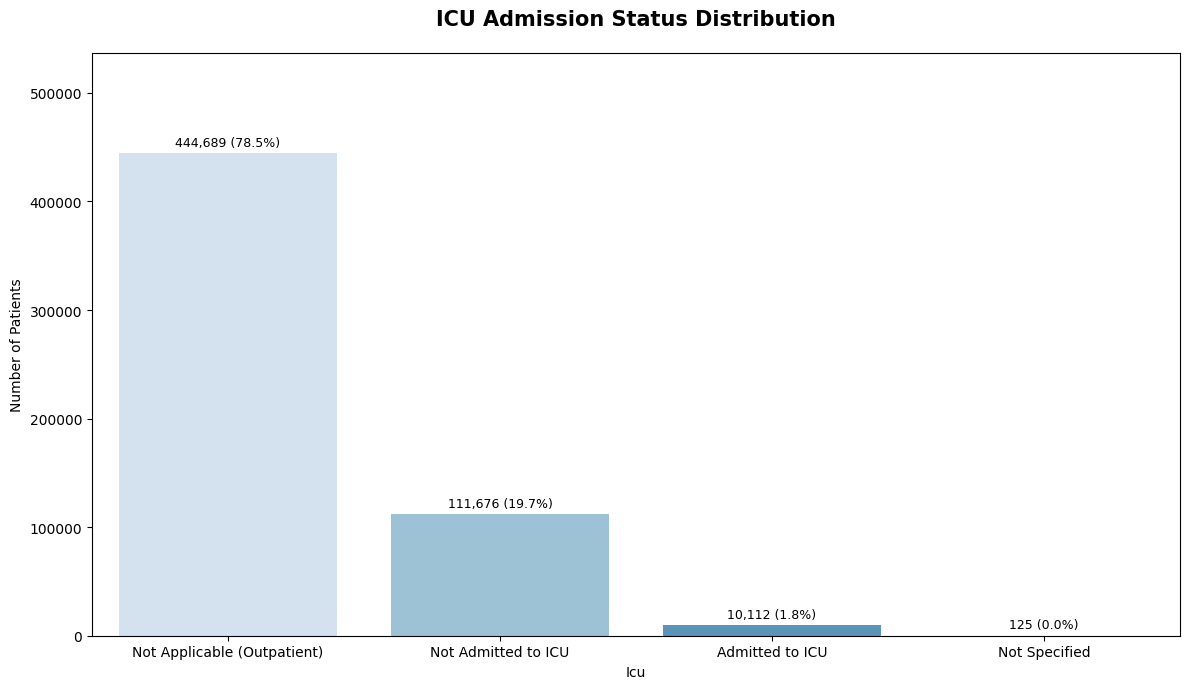


[SUMMARY TABLE: `icu`]
                              Count Percentage (%)
icu                                               
Not Applicable (Outpatient)  444689         78.48%
Not Admitted to ICU          111676         19.71%
Admitted to ICU               10112          1.78%
Not Specified                   125          0.02%
------------------------------------------------------------



In [122]:
plot_categorical_distribution(df=df_stats,
                  column='icu',
                    title='ICU Admission Status Distribution',
                    mapping={1: 'Admitted to ICU', 0: 'Not Admitted to ICU', 97: 'Not Applicable (Outpatient)', 99: 'Not Specified'})


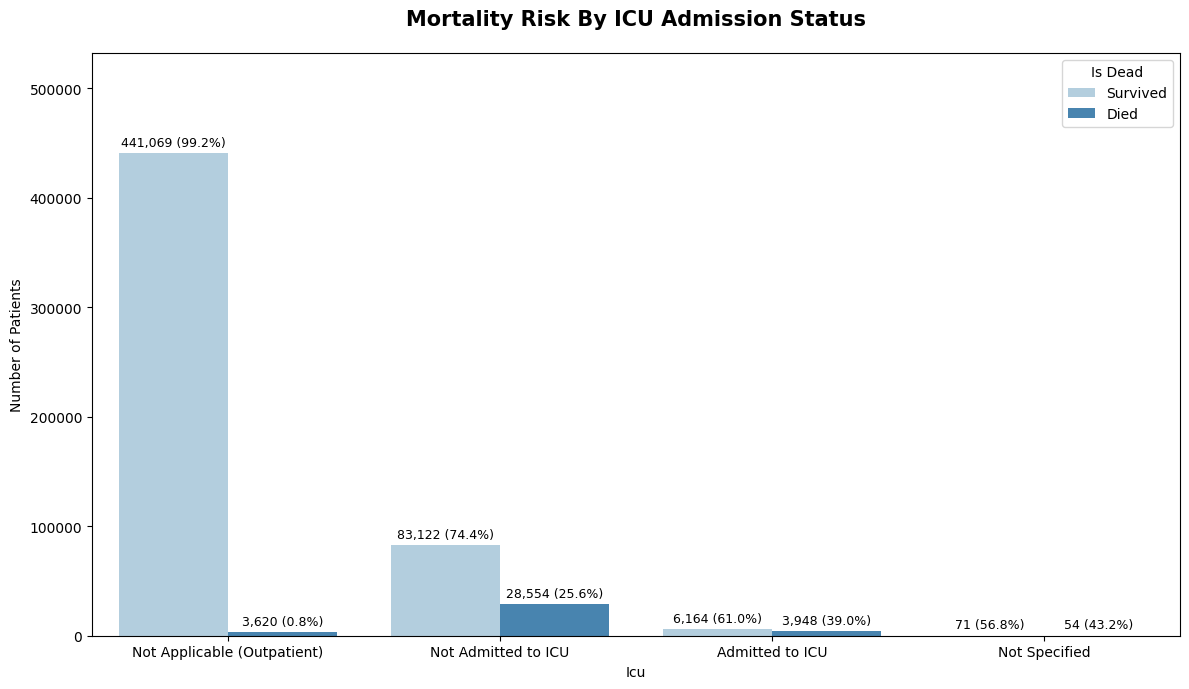


[SUMMARY TABLE: `icu` vs `is_dead`]

1. Raw Counts:
 is_dead                       Died  Survived   Total
icu                                                 
Admitted to ICU               3948      6164   10112
Not Admitted to ICU          28554     83122  111676
Not Applicable (Outpatient)   3620    441069  444689
Not Specified                   54        71     125
Total                        36176    530426  566602

2. Row-wise Percentage (Risk Analysis):
 is_dead                        Died Survived
icu                                         
Admitted to ICU              39.04%   60.96%
Not Admitted to ICU          25.57%   74.43%
Not Applicable (Outpatient)   0.81%   99.19%
Not Specified                 43.2%    56.8%
------------------------------------------------------------



In [123]:
plot_categorical_distribution(df=df_stats,
                  column='icu',
                  hue='is_dead',
                  title='Mortality Risk By ICU Admission Status',
                  mapping={
                      'icu': {1: 'Admitted to ICU', 0: 'Not Admitted to ICU', 97: 'Not Applicable (Outpatient)', 99: 'Not Specified'},
                      'is_dead': {1: 'Died', 0: 'Survived'}
                  })

### Numerical Feature - `age`

/home/thaoly/covid-19-classification/modules/eda.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp, x=column, ax=ax_box, palette=palette)
/home/thaoly/covid-19-classification/modules/eda.py:109: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=temp, x=column, kde=True, palette=palette, ax=ax_hist)


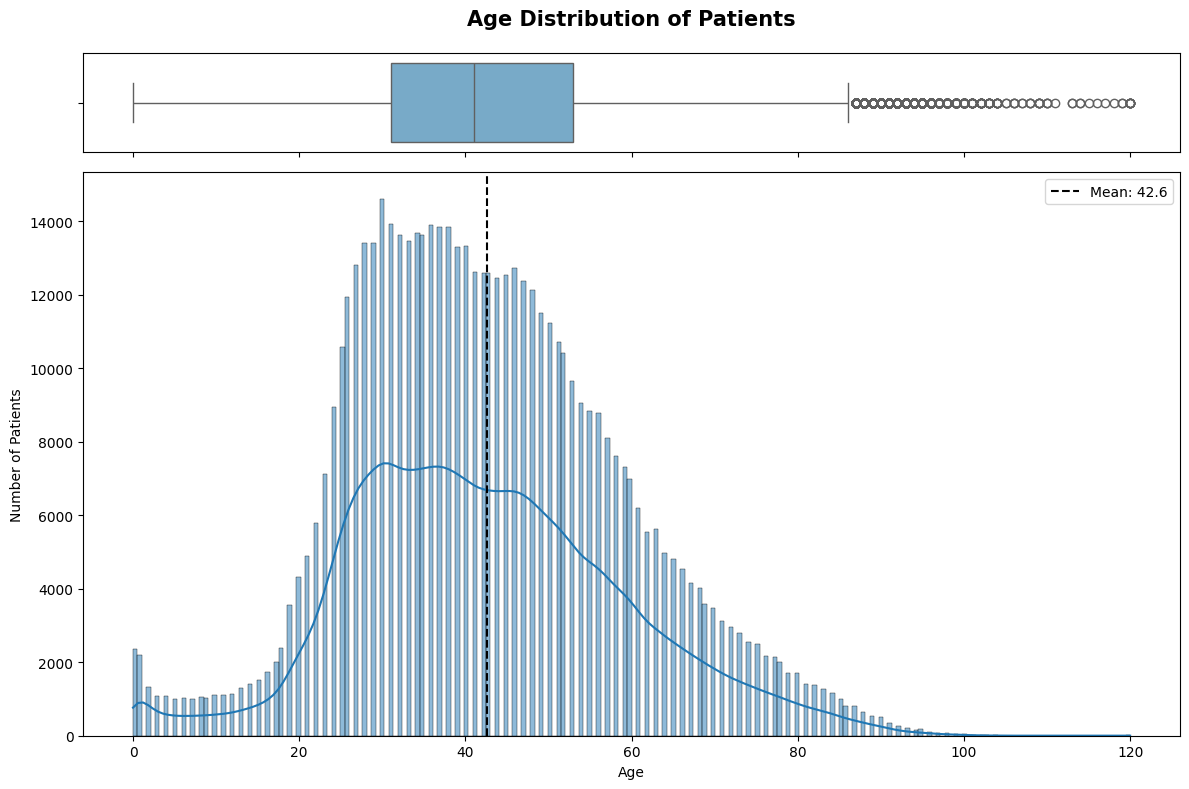


[SUMMARY STATISTICS: `AGE`]
        count   mean    std  min   25%   50%   75%    max
age  566602.0  42.62  16.66  0.0  31.0  41.0  53.0  120.0
------------------------------------------------------------



In [124]:
plot_numerical_distribution(df=df_stats, 
                       column='age', 
                       title='Age Distribution of Patients')

/home/thaoly/covid-19-classification/modules/eda.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp, x=hue, y=column, ax=axes[0], palette=palette)


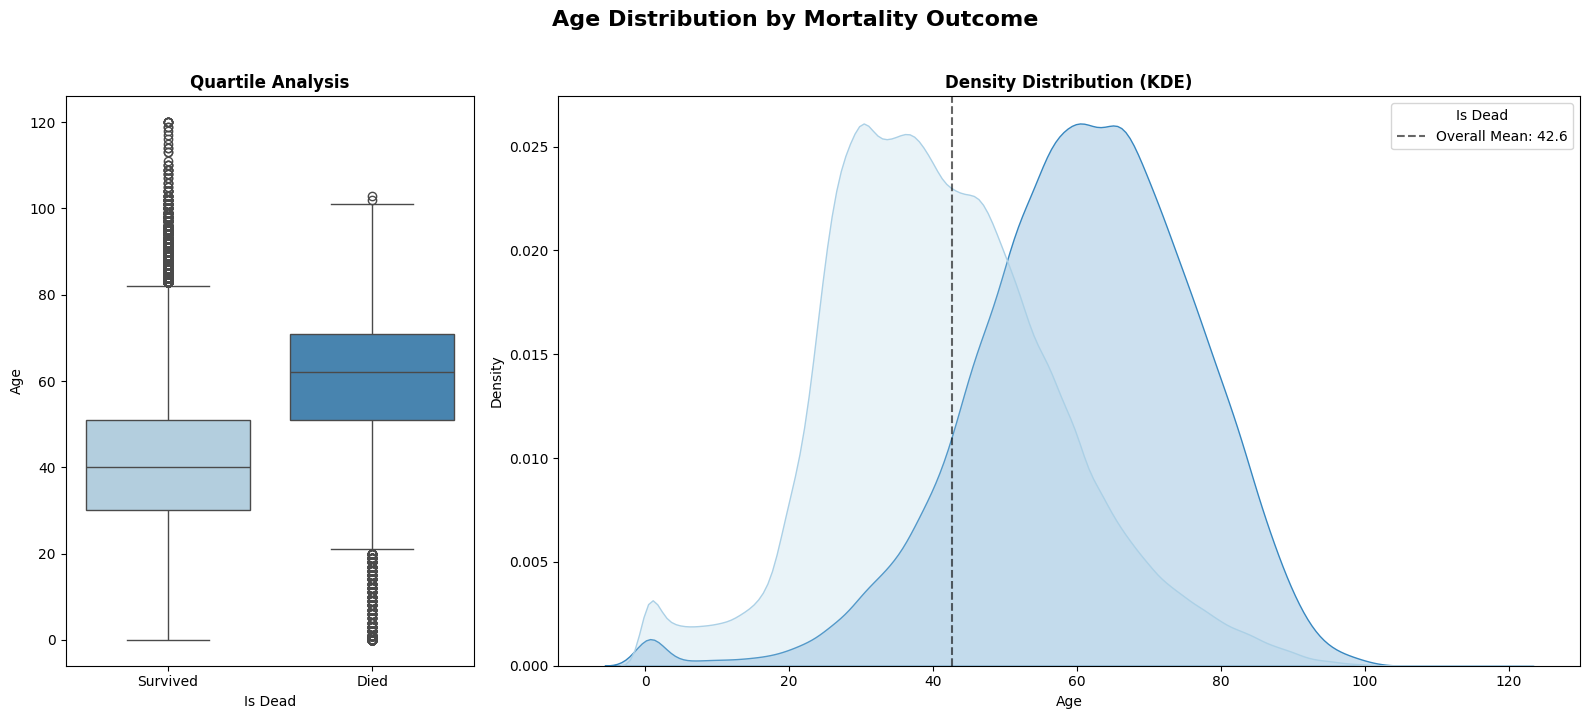


[SUMMARY STATISTICS: `AGE`]
             count   mean    std  min   25%   50%   75%    max
is_dead                                                       
Died       36176.0  60.75  15.40  0.0  51.0  62.0  71.0  103.0
Survived  530426.0  41.39  16.01  0.0  30.0  40.0  51.0  120.0
------------------------------------------------------------



In [125]:
plot_numerical_distribution(df=df_stats,
                            column='age',
                            title='Age Distribution by Mortality Outcome',
                            hue='is_dead',
                            mapping={'is_dead': {1: 'Died', 0: 'Survived'}})

#### ***Date Features***

/home/thaoly/covid-19-classification/modules/eda.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp, x=column, ax=ax_box, palette=palette)
/home/thaoly/covid-19-classification/modules/eda.py:109: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=temp, x=column, kde=True, palette=palette, ax=ax_hist)


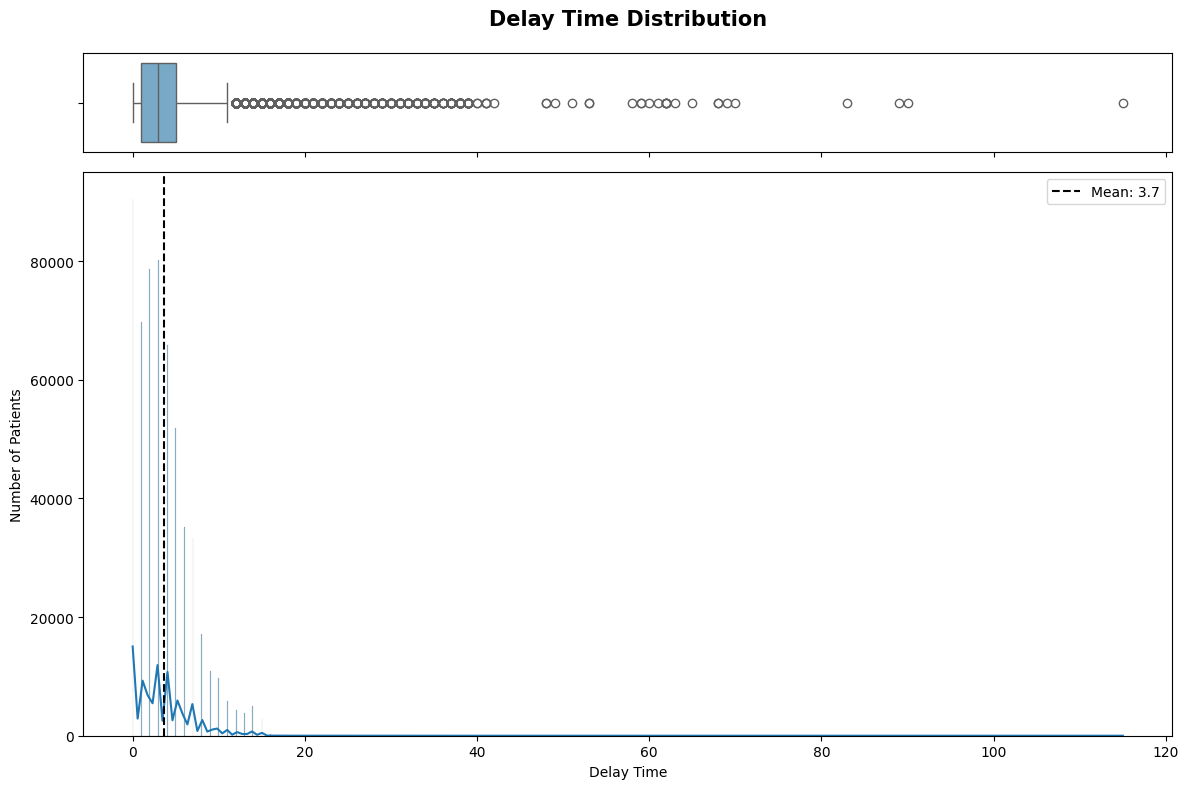


[SUMMARY STATISTICS: `DELAY_TIME`]
               count  mean   std  min  25%  50%  75%    max
delay_time  566602.0  3.67  3.28  0.0  1.0  3.0  5.0  115.0
------------------------------------------------------------



In [126]:
plot_numerical_distribution(df=df_stats,
                            column='delay_time',
                            title='Delay Time Distribution')

/home/thaoly/covid-19-classification/modules/eda.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp, x=hue, y=column, ax=axes[0], palette=palette)


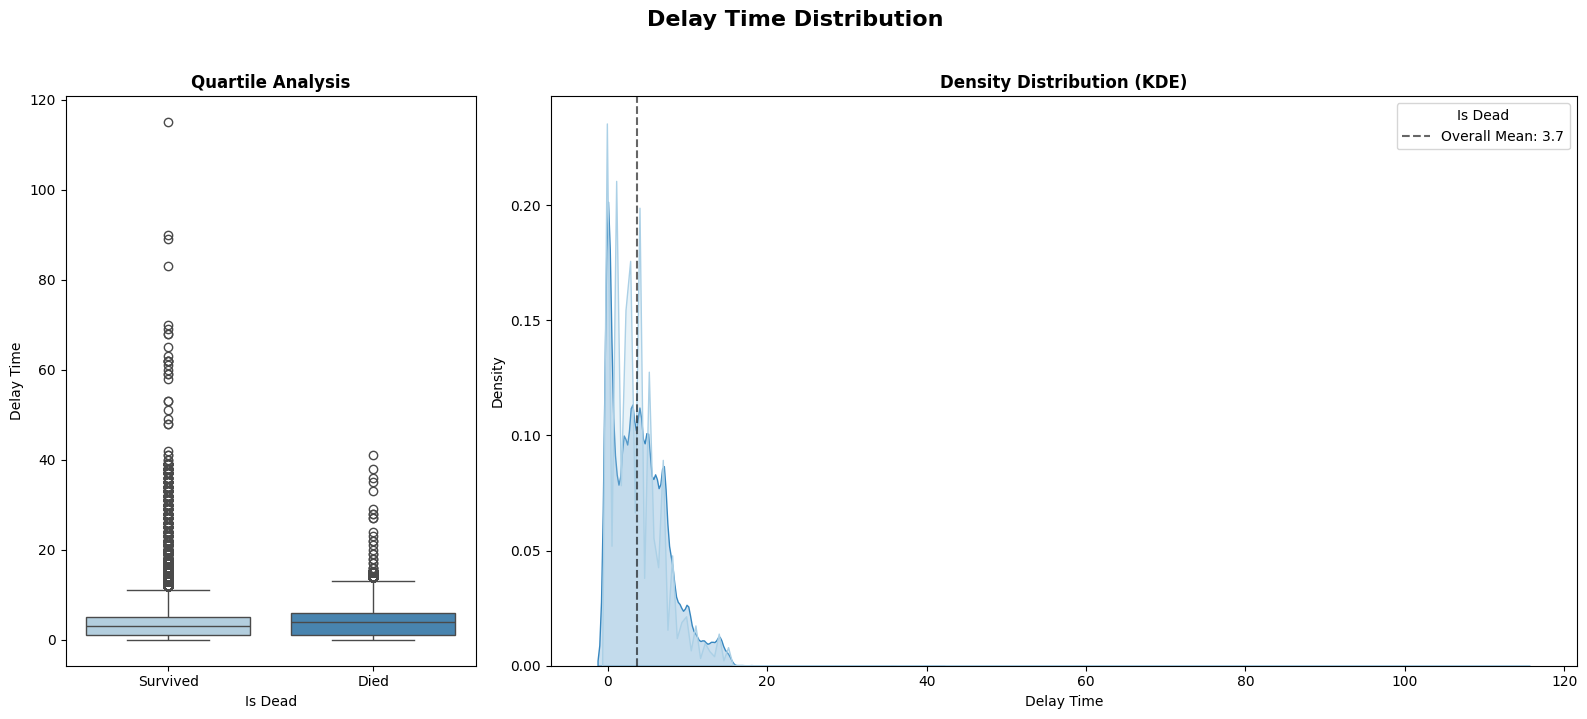


[SUMMARY STATISTICS: `DELAY_TIME`]
             count  mean   std  min  25%  50%  75%    max
is_dead                                                  
Died       36176.0  4.05  3.49  0.0  1.0  4.0  6.0   41.0
Survived  530426.0  3.64  3.26  0.0  1.0  3.0  5.0  115.0
------------------------------------------------------------



In [127]:
plot_numerical_distribution(df=df_stats,
                            column='delay_time',
                            title='Delay Time Distribution',
                            hue='is_dead',
                            mapping={'is_dead': {1: 'Died', 0: 'Survived'}})

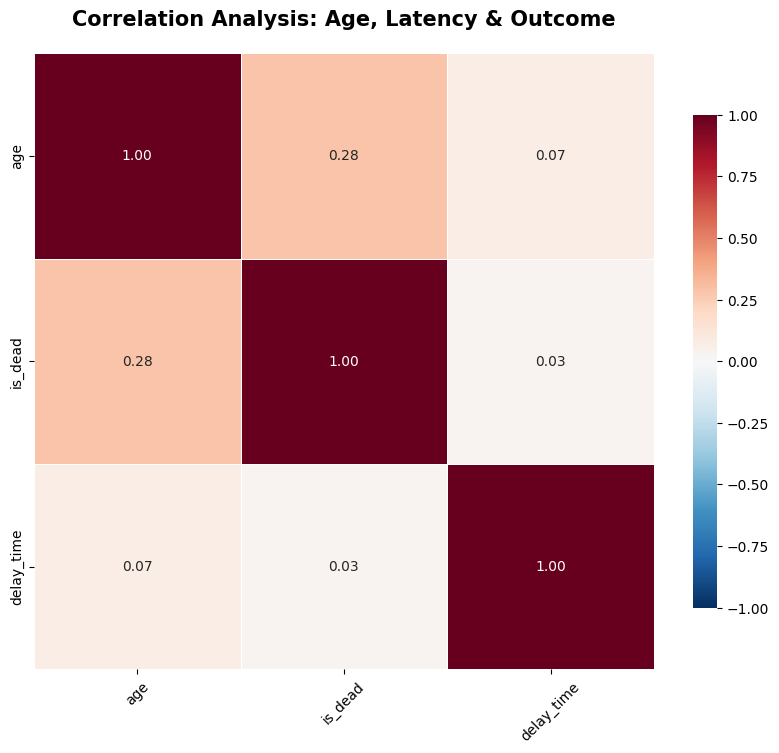


[CORRELATION COEFFICIENTS: age, is_dead, delay_time]
                 age   is_dead  delay_time
age         1.000000  0.284225    0.072481
is_dead     0.284225  1.000000    0.030204
delay_time  0.072481  0.030204    1.000000
------------------------------------------------------------



In [128]:
plot_correlation(df=df_stats, 
                 columns=[c for c in df_stats.columns if df_stats[c].dtype in ['int64', 'float64']], 
                 title="Correlation Analysis: Age, Latency & Outcome")

### Split

In [129]:
# Separate features and target
from sklearn.model_selection import train_test_split

X = df_clean.drop('is_dead', axis=1)
y = df_clean['is_dead']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## **Preprocessing**

In [130]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 566602 entries, 0 to 566601
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   sex                  566602 non-null  category
 1   patient_type         566602 non-null  category
 2   intubed              566602 non-null  category
 3   pneumonia            566602 non-null  category
 4   age                  566602 non-null  int64   
 5   pregnancy            566602 non-null  category
 6   diabetes             566602 non-null  category
 7   copd                 566602 non-null  category
 8   asthma               566602 non-null  category
 9   inmsupr              566602 non-null  category
 10  hypertension         566602 non-null  category
 11  other_disease        566602 non-null  category
 12  cardiovascular       566602 non-null  category
 13  obesity              566602 non-null  category
 14  renal_chronic        566602 non-null  category
 15  tobacco    

In [131]:
X_train_binning = apply_feature_binning(X_train)
X_test_binning = apply_feature_binning(X_test)


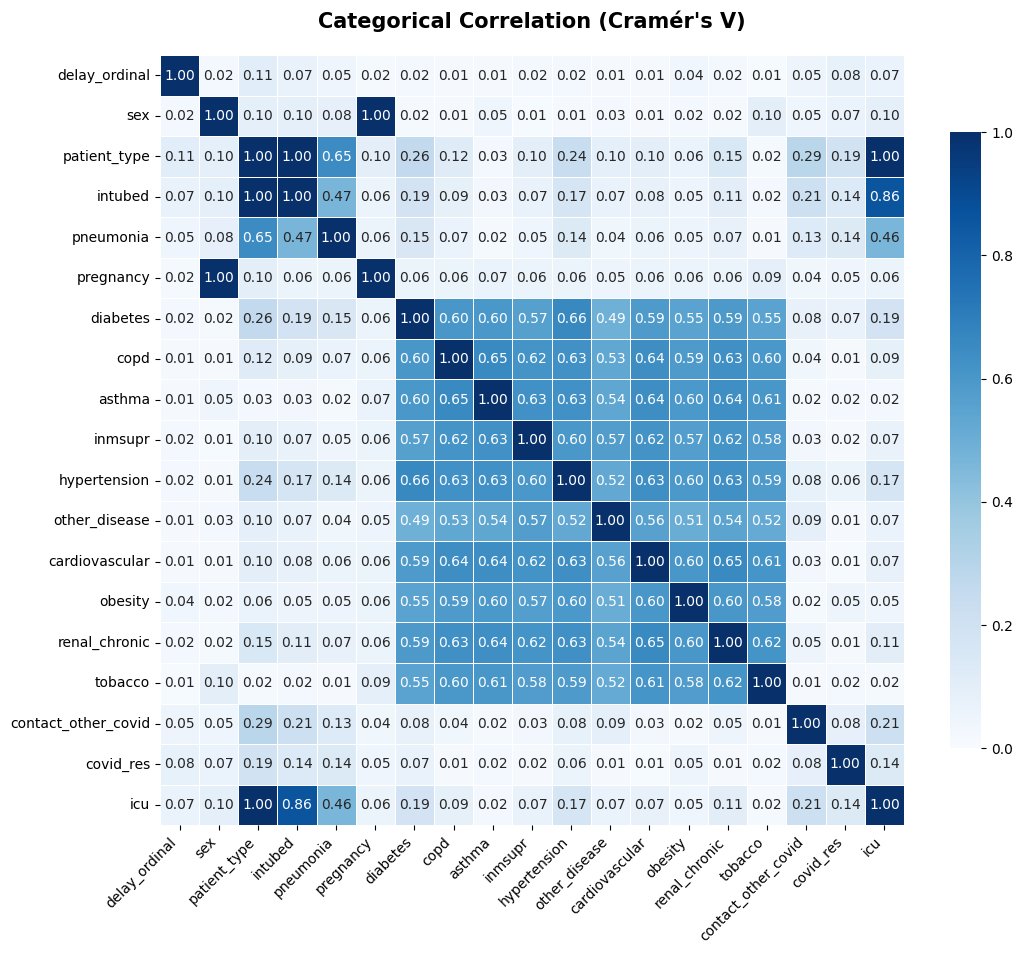


[CRAMÉR'S V STATISTICAL MATRIX]
------------------------------------------------------------

[MULTICOLLINEARITY ALERT (Threshold >= 0.7)]
 patient_type & intubed : 1.000
 sex & pregnancy : 1.000
 patient_type & icu : 1.000
 intubed & icu : 0.856
------------------------------------------------------------



In [132]:
plot_categorical_heatmap(df=X_train_binning,
                         categorical_cols=ORDINAL_FEATURES + CATEGORICAL_FEATURES
                            )

In [133]:
df_stats_binning = X_train_binning.copy()
df_stats_binning['is_dead'] = y_train

/home/thaoly/covid-19-classification/modules/eda.py:275: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Score', y='Feature', data=importance_df, palette=palette)


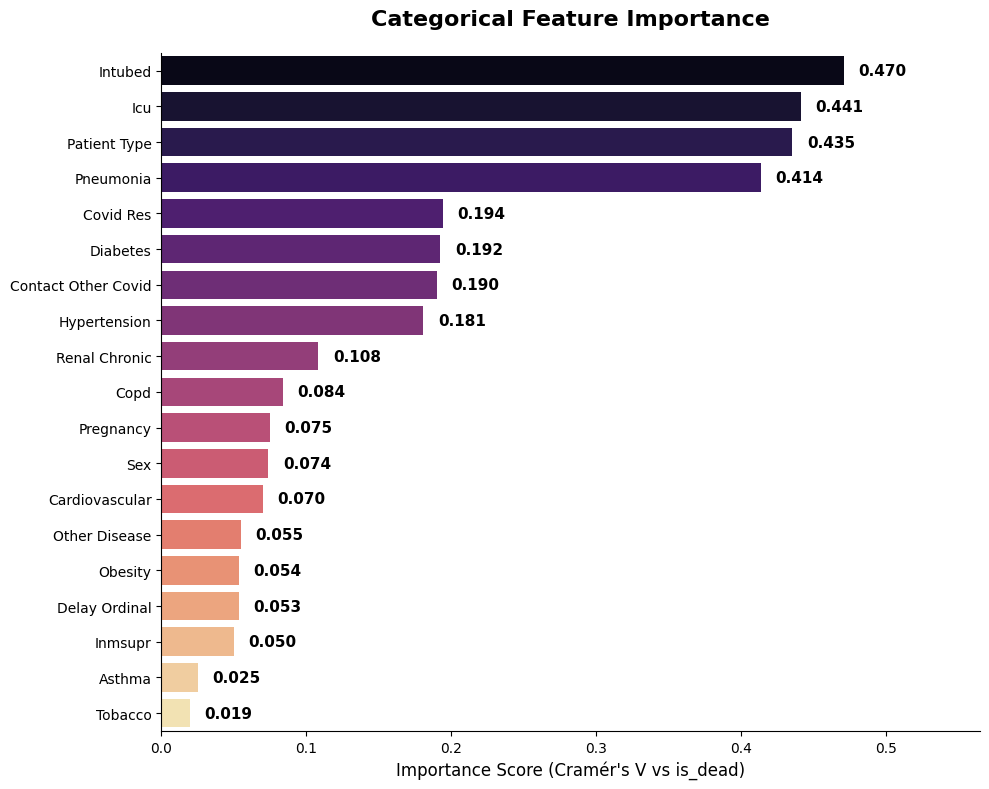


[FEATURE IMPORTANCE RANKING vs `IS_DEAD`]
            Feature    Score
            Intubed 0.470486
                Icu 0.441203
       Patient Type 0.435181
          Pneumonia 0.413567
          Covid Res 0.194342
           Diabetes 0.192444
Contact Other Covid 0.189918
       Hypertension 0.180715
      Renal Chronic 0.108323
               Copd 0.083969
          Pregnancy 0.075005
                Sex 0.073746
     Cardiovascular 0.070137
      Other Disease 0.054695
            Obesity 0.053688
      Delay Ordinal 0.053414
            Inmsupr 0.050031
             Asthma 0.025401
            Tobacco 0.019455
------------------------------------------------------------



In [134]:
plot_categorical_importance(df=df_stats_binning
                            , categorical_cols=ORDINAL_FEATURES + CATEGORICAL_FEATURES, 
                            target='is_dead', title="Categorical Feature Importance")

In [135]:
categorical_features_after_mrmr = ['intubed','contact_other_covid', 'pregnancy',
                                   'pneumonia','asthma', 'other_disease',
                                   'covid_res','cardiovascular', 'inmsupr',
                                   'tobacco',  'copd', 'obesity',
                                   'renal_chronic',
                                   'diabetes', 'hypertension'
                                   ]
ordinal_features_after_mrmr = ['delay_ordinal']

drop_cols = ['sex',
             'patient_type',
             'icu',
             ]

In [136]:
X_train_mrmr = X_train_binning.drop(columns=drop_cols, errors='ignore')
X_test_mrmr = X_test_binning.drop(columns=drop_cols, errors='ignore')

In [137]:
preprocessor = get_preprocessor(cat_cols=categorical_features_after_mrmr,
                                ord_cols=ordinal_features_after_mrmr,
                                num_cols=NUMERICAL_FEATURES)

In [138]:
X_train_processed = preprocessor.fit_transform(X_train_mrmr)
X_test_processed = preprocessor.transform(X_test_mrmr)

## **Machine Learning**

Hyperparameter tuning

Data preprocessing, including Random Unsampler, SMOTENC with ratio 1:1 and ratio 1:5

In [139]:
all_cat= categorical_features_after_mrmr + ordinal_features_after_mrmr
cat_indices = [X_train_mrmr.columns.get_loc(col) for col in all_cat if col in X_train_mrmr.columns]

In [140]:
balanced_datasets = generate_balanced_datasets(
    X_train_raw=X_train_mrmr,    
    y_train=y_train, 
    preprocessor=preprocessor,   
    cat_indices=cat_indices
)


--- BALANCING DATA WITH RANDOM UNDERSAMPLER ---
Class distribution AFTER RUS: Counter({0: 28879, 1: 28879})
RUS took 0.22 seconds.

--- BALANCING DATA WITH SMOTE-NC (1:1) ---
Class distribution AFTER SMOTE:  Counter({0: 424402, 1: 424402})
SMOTE-NC took 235.93 seconds.

--- BALANCING DATA WITH SMOTE-NC (1:5) ---
Class distribution AFTER SMOTE (1:5):  Counter({0: 424402, 1: 84880})
SMOTE-NC (1:5) took 131.14 seconds.


Tuning with Random Undersampler Data

In [ ]:
X_train_rus, y_train_rus = balanced_datasets['Original + RUS']
results_rus = train_and_evaluate_pipeline(X_train_bal=X_train_rus, 
                                          y_train_bal=y_train_rus, 
                                          X_test_proc=X_test_processed, 
                                          y_test=y_test, 
                                          dataset_name="RUS")


 INITIATING PIPELINE FOR: RUS
Đang tìm tham số tối ưu cho Logistic Regression...


Tuning with SMOTENC 1:1 data

In [ ]:
X_train_1_1, y_train_1_1 = balanced_datasets['SMOTE-NC (1:1 Ratio)']
results_smote_1_1 = train_and_evaluate_pipeline(X_train_bal=X_train_1_1, 
                                                y_train_bal=y_train_1_1, 
                                                X_test_proc=X_test_processed, 
                                                y_test=y_test, 
                                                dataset_name="SMOTE-NC (1:1 Ratio)")

Tuning with SMOTENC 1:5 data

In [ ]:
X_train_1_5, y_train_1_5 = balanced_datasets['SMOTE-NC (1:5 Ratio)']
results_smote_1_5 = train_and_evaluate_pipeline(X_train_bal=X_train_1_5, 
                                                y_train_bal=y_train_1_5, 
                                                X_test_proc=X_test_processed, 
                                                y_test=y_test, 
                                                dataset_name="SMOTE-NC (1:5 Ratio)")

In [ ]:
# Concatenate all results for a final comparison table
final_results_df = pd.concat([results_rus, results_smote_1_1, results_smote_1_5], ignore_index=True)
print("\n--- FINAL COMPARISON OF MODEL PERFORMANCE ---")
display(final_results_df)

# **Deep Learning**

## **Keras MLP**

### Training ###

In [ ]:
rus = RandomUnderSampler(sampling_strategy=1, random_state=42)

In [ ]:
# ==========================================
# 1. EVALUATE KERAS MLP ON 3 DATASETS
# ==========================================

# 1.1 Run on original MRMR selected data (Un-SMOTEd)
print(">>> KERAS MLP ON UN-SMOTED DATA <<<")
mlp_model_orig, mlp_hist_orig = evaluate_dl_model(
    X_train_processed, y_train,
    X_test_processed, y_test,
    preprocessor,
    undersampler=None, # Không dùng RUS để so sánh công bằng với Ensemble
    dataset_type="Un-SMOTEd"
)

# 1.2 Run on SMOTE-NC balanced data (Tỷ lệ 1:1)
print(">>> KERAS MLP ON SMOTED DATA (1:1) <<<")
mlp_model_smote, mlp_hist_smote = evaluate_dl_model(
    X_train_1_1, y_train_1_1,
    X_test_processed, y_test,
    preprocessor,
    undersampler=None,
    dataset_type="SMOTEd"
)

# 1.3 Run on SMOTE-NC balanced data (Tỷ lệ 1:5)
print(">>> KERAS MLP ON SMOTED DATA (1:5 RATIO) <<<")
mlp_model_ratio, mlp_hist_ratio = evaluate_dl_model(
    X_train_1_5, y_train_1_5,
    X_test_processed, y_test,
    preprocessor,
    undersampler=None,
    dataset_type="SMOTEd (1:5 Ratio)"
)

### Evaluation

In [ ]:
# ==========================================
# 1. EVALUATE KERAS MLP ON 3 DATASETS
# ==========================================

# 1.1 Run on original MRMR selected data (Un-SMOTEd)
print(">>> KERAS MLP ON UN-SMOTED DATA <<<")
mlp_model_orig, mlp_hist_orig = evaluate_dl_model(
    X_train_processed, y_train,
    X_test_processed, y_test,
    preprocessor,
    undersampler=rus, # Không dùng RUS để so sánh công bằng với Ensemble
    dataset_type="Un-SMOTEd"
)

# 1.2 Run on SMOTE-NC balanced data (Tỷ lệ 1:1)
print(">>> KERAS MLP ON SMOTED DATA (1:1) <<<")
mlp_model_smote, mlp_hist_smote = evaluate_dl_model(
    X_train_1_1, y_train_1_1,
    X_test_processed, y_test,
    preprocessor,
    undersampler=rus,
    dataset_type="SMOTEd"
)

# 1.3 Run on SMOTE-NC balanced data (Tỷ lệ 1:5)
print(">>> KERAS MLP ON SMOTED DATA (1:5 RATIO) <<<")
mlp_model_ratio, mlp_hist_ratio = evaluate_dl_model(
    X_train_1_5, y_train_1_5,
    X_test_processed, y_test,
    preprocessor,
    undersampler=rus,
    dataset_type="SMOTEd (1:5 Ratio)"
)

## **Tabular ResNet**

### Training

In [ ]:
# ==========================================
# 2. EVALUATE TABULAR RESNET ON 3 DATASETS
# ==========================================

# 2.1 Run on original MRMR selected data
print(">>> TABULAR RESNET ON UN-SMOTED DATA <<<")
resnet_model_orig, resnet_hist_orig = evaluate_resnet_model(
    X_train_processed, y_train,
    X_test_processed, y_test,
    preprocessor,
    undersampler=None,
    dataset_type="Un-SMOTEd"
)

# 2.2 Run on SMOTE-NC balanced data (Tỷ lệ 1:1)
print(">>> TABULAR RESNET ON SMOTED DATA (1:1) <<<")
resnet_model_smote, resnet_hist_smote = evaluate_resnet_model(
    X_train_1_1, y_train_1_1,
    X_test_processed, y_test,
    preprocessor,
    undersampler=None,
    dataset_type="SMOTEd"
)

# 2.3 Run on SMOTE-NC balanced data (Tỷ lệ 1:5)
print(">>> TABULAR RESNET ON SMOTED DATA (1:5 RATIO) <<<")
resnet_model_ratio, resnet_hist_ratio = evaluate_resnet_model(
    X_train_1_5, y_train_1_5,
    X_test_processed, y_test,
    preprocessor,
    undersampler=None,
    dataset_type="SMOTEd (1:5 Ratio)"
)

In [ ]:
# ==========================================
# 2. EVALUATE TABULAR RESNET ON 3 DATASETS
# ==========================================

# 2.1 Run on original MRMR selected data
print(">>> TABULAR RESNET ON UN-SMOTED DATA <<<")
resnet_model_orig, resnet_hist_orig = evaluate_resnet_model(
    X_train_processed, y_train,
    X_test_processed, y_test,
    preprocessor,
    undersampler=rus,
    dataset_type="Un-SMOTEd"
)

# 2.2 Run on SMOTE-NC balanced data (Tỷ lệ 1:1)
print(">>> TABULAR RESNET ON SMOTED DATA (1:1) <<<")
resnet_model_smote, resnet_hist_smote = evaluate_resnet_model(
    X_train_1_1, y_train_1_1,
    X_test_processed, y_test,
    preprocessor,
    undersampler=rus,
    dataset_type="SMOTEd"
)

# 2.3 Run on SMOTE-NC balanced data (Tỷ lệ 1:5)
print(">>> TABULAR RESNET ON SMOTED DATA (1:5 RATIO) <<<")
resnet_model_ratio, resnet_hist_ratio = evaluate_resnet_model(
    X_train_1_5, y_train_1_5,
    X_test_processed, y_test,
    preprocessor,
    undersampler=rus,
    dataset_type="SMOTEd (1:5 Ratio)"
)

## **TabNet**

In [ ]:
# ==========================================
# 3. EVALUATE TABNET ON 3 DATASETS
# ==========================================

# 3.1 Run on original MRMR selected data
print(">>> TABNET ON UN-SMOTED DATA <<<")
tabnet_model_orig, tabnet_feat_orig = evaluate_tabnet_model(
    X_train_processed, y_train,
    X_test_processed, y_test,
    preprocessor,
    undersampler=None,
    dataset_type="Un-SMOTEd"
)

# 3.2 Run on SMOTE-NC balanced data (Tỷ lệ 1:1)
print(">>> TABNET ON SMOTED DATA (1:1) <<<")
tabnet_model_smote, tabnet_feat_smote = evaluate_tabnet_model(
    X_train_1_1, y_train_1_1,
    X_test_processed, y_test,
    preprocessor,
    undersampler=None,
    dataset_type="SMOTEd"
)

# 3.3 Run on SMOTE-NC balanced data (Tỷ lệ 1:5)
print(">>> TABNET ON SMOTED DATA (1:5 RATIO) <<<")
tabnet_model_ratio, tabnet_feat_ratio = evaluate_tabnet_model(
    X_train_1_5, y_train_1_5,
    X_test_processed, y_test,
    preprocessor,
    undersampler=None,
    dataset_type="SMOTEd (1:5 Ratio)"
)

In [ ]:
# ==========================================
# 3. EVALUATE TABNET ON 3 DATASETS
# ==========================================

# 3.1 Run on original MRMR selected data
print(">>> TABNET ON UN-SMOTED DATA <<<")
tabnet_model_orig, tabnet_feat_orig = evaluate_tabnet_model(
    X_train_processed, y_train,
    X_test_processed, y_test,
    preprocessor,
    undersampler=rus,
    dataset_type="Un-SMOTEd"
)

# 3.2 Run on SMOTE-NC balanced data (Tỷ lệ 1:1)
print(">>> TABNET ON SMOTED DATA (1:1) <<<")
tabnet_model_smote, tabnet_feat_smote = evaluate_tabnet_model(
    X_train_1_1, y_train_1_1,
    X_test_processed, y_test,
    preprocessor,
    undersampler=rus,
    dataset_type="SMOTEd"
)

# 3.3 Run on SMOTE-NC balanced data (Tỷ lệ 1:5)
print(">>> TABNET ON SMOTED DATA (1:5 RATIO) <<<")
tabnet_model_ratio, tabnet_feat_ratio = evaluate_tabnet_model(
    X_train_1_5, y_train_1_5,
    X_test_processed, y_test,
    preprocessor,
    undersampler=rus,
    dataset_type="SMOTEd (1:5 Ratio)"
)